# LS 2.0 Facility Survey — Analytics & Visualisation

Thirty decision questions the LS 2.0 questionnaire was designed to answer, each worked end to end:
the **SQL** run against the SQLite warehouse built by the ETL (`outputs/ls2_survey.db`), the **result table**,
an **interactive Plotly figure**, and the **answer** in plain language.

The notebook is generated from `src/analysis/questions.py`, so the code shown in each cell is exactly the code the
pipeline runs. Re-run all cells after `python run_pipeline.py` to refresh every answer.

> The dataset is generated from the structure of the questionnaire (184 facilities × 6 bi-weekly rounds).
> The pipeline, SQL and charts run unchanged on a real export with the same sheet layout.

**Contents**

| Section | Questions |
|---|---|
| Facility access & cold chain | Q01–Q04 |
| Service delivery | Q05–Q07 |
| Human resources for health | Q08–Q14 |
| Supply chain | Q15–Q21 |
| Vaccines | Q22–Q24 |
| Composite readiness & predictors | Q25–Q30 |


In [1]:
import sqlite3, sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
import config as C
from analysis import theme as T                       # shared Plotly template (registered as "ls2")
from analysis.questions import Result, q, pct, hbar   # helpers used by every question below

# Interactive figure in Jupyter / VS Code / nbviewer, plus a static PNG so GitHub renders it
pio.renderers.default = "notebook_connected+png"
pio.templates.default = "ls2"
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160); pd.set_option("display.float_format", "{:.3f}".format)

con = sqlite3.connect(ROOT / "outputs" / "ls2_survey.db")
print(pd.read_sql_query("SELECT table_name, row_count FROM etl_log ORDER BY row_count DESC", con).to_string(index=False))


              table_name  row_count
         commodity_stock      25392
       staffing_by_cadre       9936
        service_sessions       8832
           vaccine_stock       7854
    cold_chain_equipment       7728
          visit_services       7470
visit_vaccines_dispensed       5070
         absence_reasons       4262
         visit_cce_types       3756
 visit_requisition_types       1502
   visit_vaccine_sources       1367
         facility_visits       1104
 visit_commodity_sources       1097
               trainings        618
     visit_salary_issues        552
              facilities        184


## The warehouse

`facility_visits` is the fact table (one row per facility per round). Long tables hang off it by `visit_id`, and the views
`v_visits`, `v_commodity`, `v_staffing`, `v_absence`, `v_vaccine` and `v_sessions` pre-join facility context.


In [2]:
views = pd.read_sql_query("SELECT name, type FROM sqlite_master WHERE type IN ('table','view') ORDER BY type, name", con)
print(", ".join(views[views.type == "view"].name), "\n")
pd.read_sql_query("SELECT * FROM v_visits LIMIT 3", con).T.head(40)


v_absence, v_commodity, v_sessions, v_staffing, v_vaccine, v_visits 



,0,1,2
visit_id,KD-001-R1,KD-001-R2,KD-001-R3
facility_id,KD-001,KD-001,KD-001
round_number,1,2,3
round_name,Baseline,Bi-weekly 1,Bi-weekly 2
visit_date,2026-03-02,2026-03-17,2026-03-31
data_champion,Bala Danladi,Bala Danladi,Bala Danladi
respondent_name,Zainab Ishaya,Zainab Ishaya,Zainab Ishaya
respondent_cadre,Pharmacy Technician,Pharmacy Technician,Pharmacy Technician
respondent_position,OIC,OIC,OIC
hours_of_operation,24 hours,24 hours,24 hours


In [3]:
results = []

---
# Facility access

## Q01. How often are facilities actually open when a data champion arrives, and where is access weakest?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [4]:
def q01(con):
    sql = """
    SELECT lga, COUNT(*) AS visits, AVG(facility_open_on_arrival_flag) AS open_rate,
           AVG(CASE WHEN facility_open_on_arrival_flag=0 THEN wait_minutes END) AS avg_wait_when_closed
    FROM v_visits GROUP BY lga ORDER BY open_rate"""
    df = q(con, sql)
    overall = q(con, "SELECT AVG(facility_open_on_arrival_flag) r, AVG(CASE WHEN facility_open_on_arrival_flag=0 THEN wait_minutes END) w FROM v_visits").iloc[0]
    worst, best = df.iloc[0], df.iloc[-1]
    fig = hbar(df, "open_rate", "lga", "Share of visits where the facility was open on arrival, by LGA", xlabel="Open on arrival")
    fig.add_vline(x=overall.r, line_dash="dot", line_color=T.TEXT_SECONDARY, annotation_text=f"State avg {pct(overall.r)}", annotation_position="top")
    ans = (f"Facilities were open on arrival in {pct(overall.r)} of {int(df.visits.sum())} visits. Where closed, data champions "
           f"waited {overall.w:.0f} minutes on average. {worst.lga} is the weakest LGA ({pct(worst.open_rate)}) and "
           f"{best.lga} the strongest ({pct(best.open_rate)}).")
    return Result("Q01", "Facility access", "How often are facilities actually open when a data champion arrives, and where is access weakest?",
                  sql, df, ans, fig, key_numbers={"open_on_arrival_rate": float(overall.r), "avg_wait_minutes": float(overall.w)})

,lga,visits,open_rate,avg_wait_when_closed
0,Kauru,48,0.688,45.333
1,Igabi,48,0.708,52.786
2,Chikun,48,0.729,52.615
3,Jema'a,48,0.729,55.846
4,Kachia,48,0.729,43.231
5,Zangon Kataf,48,0.729,42.000
6,Sabon Gari,48,0.750,49.250
7,Birnin Gwari,48,0.771,64.000
8,Soba,48,0.771,40.545
9,Giwa,48,0.792,53.400


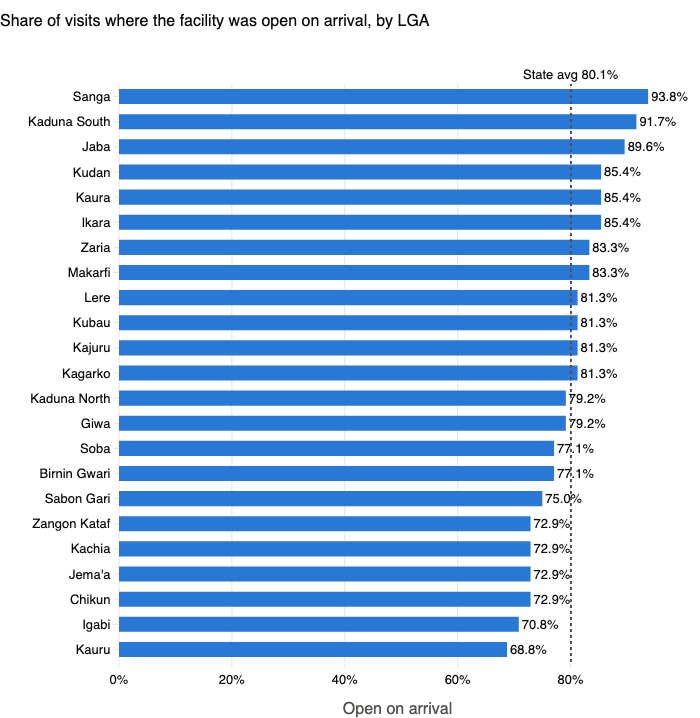

Facilities were open on arrival in 80.1% of 1104 visits. Where closed, data champions waited 46 minutes on average. Kauru is the weakest LGA (68.8%) and Sanga the strongest (93.8%).


In [5]:
r = q01(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q02. What are the main reasons facilities are closed when visited?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [6]:
def q02(con):
    sql = """
    SELECT reason_closed_on_arrival AS reason, COUNT(*) AS n
    FROM v_visits WHERE facility_open_on_arrival_flag=0 GROUP BY 1 ORDER BY n DESC"""
    df = q(con, sql); df["share"] = df.n / df.n.sum()
    fig = hbar(df, "share", "reason", "Why facilities were closed on arrival", xlabel="Share of closed-on-arrival visits")
    top = df.iloc[0]
    ans = (f"The leading cause of a closed facility is '{top.reason}' ({pct(top.share)} of {int(df.n.sum())} cases). "
           f"Insecurity accounts for {pct(df.loc[df.reason=='Facility closed due to insecurity','share'].sum())}, concentrated in security-risk LGAs.")
    return Result("Q02", "Facility access", "What are the main reasons facilities are closed when visited?", sql, df, ans, fig)

,reason,n,share
0,Staff not yet arrived,66,0.300
1,Facility closed due to insecurity,39,0.177
2,Staff at LGA meeting or training,35,0.159
3,Staff gone to collect vaccines/commodities,27,0.123
4,Other,23,0.105
5,No staff posted on this shift,20,0.091
6,Public holiday,10,0.045


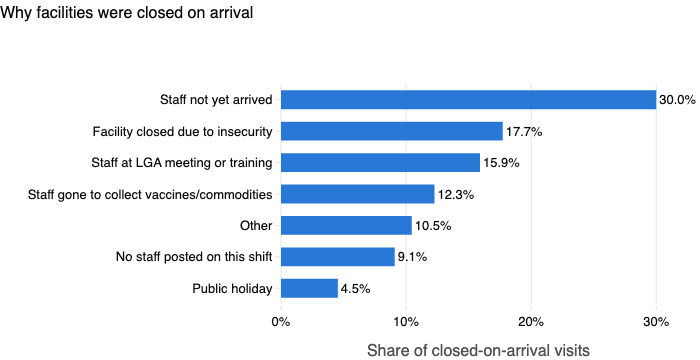

The leading cause of a closed facility is 'Staff not yet arrived' (30.0% of 220 cases). Insecurity accounts for 17.7%, concentrated in security-risk LGAs.


In [7]:
r = q02(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q03. What are facility operating hours, and can facilities refer emergencies with transport?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [8]:
def q03(con):
    sql = """
    SELECT facility_type, hours_of_operation, COUNT(DISTINCT facility_id) AS facilities
    FROM v_visits WHERE round_number=1 GROUP BY 1,2"""
    df = q(con, sql)
    fig = px.bar(df, x="facility_type", y="facilities", color="hours_of_operation", barmode="stack",
                 title="Hours of operation by facility type (baseline)",
                 category_orders={"hours_of_operation": C.HOURS_OF_OPERATION, "facility_type": C.FACILITY_TYPES},
                 color_discrete_sequence=T.SERIES)
    fig.update_traces(marker_line_color="#fff", marker_line_width=2, width=0.6)
    fig.update_layout(xaxis_title="", yaxis_title="Facilities", legend_title="")
    tot = df.groupby("hours_of_operation").facilities.sum(); share24 = tot.get("24 hours", 0) / tot.sum()
    ref = q(con, "SELECT AVG(can_refer_emergencies_flag) r, AVG(emergency_transport_available_2wks_flag) t FROM v_visits").iloc[0]
    ans = (f"{pct(share24)} of facilities report 24-hour operation, driven by PHCs and General Hospitals; most Health Posts run 6-8 hour days. "
           f"{pct(ref.r)} of visits confirmed the facility can refer obstetric emergencies, but transport was available when needed in only {pct(ref.t)} of those.")
    return Result("Q03", "Facility access", "What are facility operating hours, and can facilities refer emergencies with transport?", sql, df, ans, fig,
                  key_numbers={"share_24h": float(share24), "can_refer": float(ref.r), "transport_available": float(ref.t)})

,facility_type,hours_of_operation,facilities
0,Basic Health Centre,12 hours,12
1,Basic Health Centre,24 hours,10
2,Basic Health Centre,6-8 hours,19
3,Basic Health Centre,<5 hours,7
4,General Hospital,12 hours,6
5,General Hospital,24 hours,9
6,General Hospital,6-8 hours,3
7,Health Post,12 hours,8
8,Health Post,24 hours,9
9,Health Post,6-8 hours,16


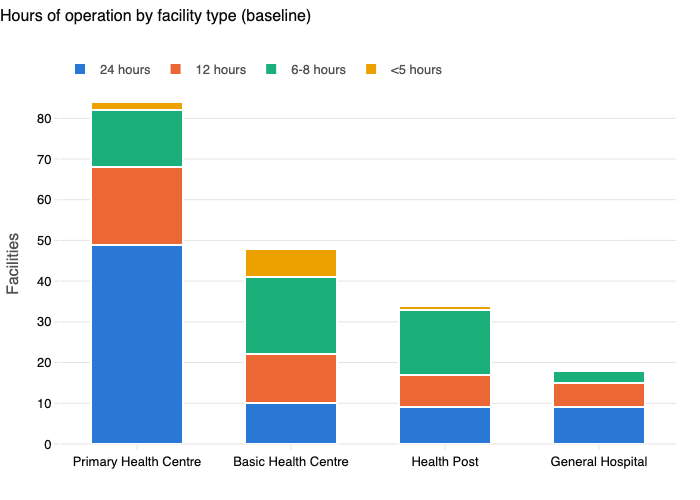

41.8% of facilities report 24-hour operation, driven by PHCs and General Hospitals; most Health Posts run 6-8 hour days. 78.2% of visits confirmed the facility can refer obstetric emergencies, but transport was available when needed in only 59.1% of those.


In [9]:
r = q03(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

---
# Cold chain

## Q04. How functional is the cold chain, and how often is it interrupted?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [10]:
def q04(con):
    sql = """
    SELECT cce_type, AVG(available_flag) AS availability,
           AVG(CASE WHEN available_flag=1 THEN functional_flag END) AS functionality
    FROM cold_chain_equipment GROUP BY cce_type ORDER BY functionality"""
    df = q(con, sql)
    long = df.melt(id_vars="cce_type", var_name="metric", value_name="rate")
    fig = px.bar(long, x="rate", y="cce_type", color="metric", barmode="group", orientation="h",
                 title="Cold chain equipment: availability vs functionality", color_discrete_sequence=T.SERIES, text="rate")
    fig.update_traces(texttemplate="%{text:.0%}", textposition="outside", cliponaxis=False, width=0.35)
    fig.update_layout(xaxis_tickformat=".0%", xaxis_title="", yaxis_title="", legend_title="", height=420)
    intr = q(con, """SELECT AVG(cold_chain_interruption_since_last_visit_flag) r FROM v_visits WHERE has_cold_chain_equipment_flag=1""").iloc[0].r
    reason = q(con, """SELECT cold_chain_interruption_reason reason, COUNT(*) n FROM v_visits WHERE cold_chain_interruption_since_last_visit_flag=1 GROUP BY 1 ORDER BY n DESC""").iloc[0]
    fridge = q(con, "SELECT AVG(vaccine_fridge_functional_flag) r FROM v_visits WHERE has_cold_chain_equipment_flag=1").iloc[0].r
    ans = (f"Where equipment exists, functionality ranges from {pct(df.functionality.min())} ({df.iloc[0].cce_type}) to {pct(df.functionality.max())} ({df.iloc[-1].cce_type}). "
           f"Only {pct(fridge)} of facilities with cold chain equipment have at least one working vaccine refrigerator, and {pct(intr)} of visits recorded a cold chain interruption since the previous visit, "
           f"most often '{reason.reason}'.")
    return Result("Q04", "Cold chain", "How functional is the cold chain, and how often is it interrupted?", sql, df, ans, fig,
                  key_numbers={"fridge_functional_rate": float(fridge), "interruption_rate": float(intr)})

,cce_type,availability,functionality
0,Rush (3L),0.277,0.745
1,Cold Boxes (6L),0.598,0.774
2,Solar Refrigerators and Freezers,0.527,0.789
3,Ice Packs,0.701,0.793
4,GioStyle (4L),0.462,0.796
5,Temperature Monitoring Devices,0.592,0.804
6,Refrigerators,0.245,0.822


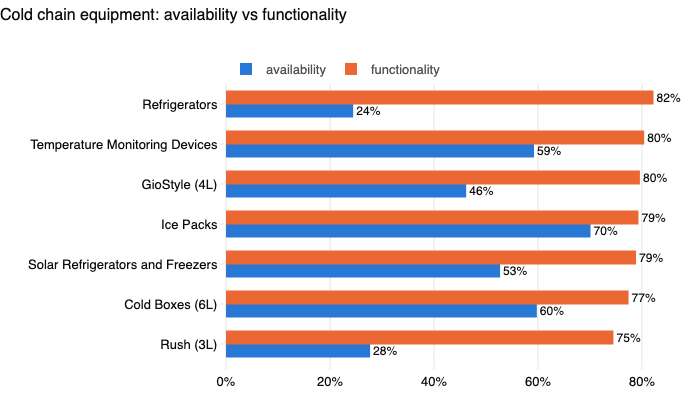

Where equipment exists, functionality ranges from 74.5% (Rush (3L)) to 82.2% (Refrigerators). Only 66.4% of facilities with cold chain equipment have at least one working vaccine refrigerator, and 20.7% of visits recorded a cold chain interruption since the previous visit, most often 'Power failure / no electricity'.


In [11]:
r = q04(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

---
# Service delivery

## Q05. Which services do facilities offer, and how reliably are planned sessions delivered?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [12]:
def q05(con):
    sql = """
    SELECT service, AVG(offered_flag) AS offered_rate,
           AVG(all_conducted_flag) AS session_completion_rate
    FROM service_sessions GROUP BY service ORDER BY session_completion_rate"""
    df = q(con, sql)
    long = df.melt(id_vars="service", var_name="metric", value_name="rate")
    fig = px.bar(long, x="rate", y="service", color="metric", barmode="group", orientation="h",
                 title="Service availability and completion of planned sessions (last week)", color_discrete_sequence=T.SERIES, text="rate")
    fig.update_traces(texttemplate="%{text:.0%}", textposition="outside", cliponaxis=False, width=0.35)
    fig.update_layout(xaxis_tickformat=".0%", xaxis_title="", yaxis_title="", legend_title="", height=440)
    ans = (f"Malaria and ANC are near-universal, while Nutrition ({pct(df.set_index('service').loc['Nutrition','offered_rate'])}) and Labour & Delivery are the least available. "
           f"Planned sessions were fully delivered in {pct(df.session_completion_rate.mean())} of service-weeks; {df.iloc[0].service} has the lowest completion ({pct(df.iloc[0].session_completion_rate)}).")
    return Result("Q05", "Service delivery", "Which services do facilities offer, and how reliably are planned sessions delivered?", sql, df, ans, fig)

,service,offered_rate,session_completion_rate
0,Immunization,0.810,0.754
1,Nutrition,0.696,0.763
2,Labour and Delivery,0.772,0.775
3,Family Planning,0.891,0.779
4,Antenatal Care,0.897,0.788
5,IMCI,0.837,0.789
6,Postnatal Care,0.891,0.791
7,Malaria,0.973,0.798


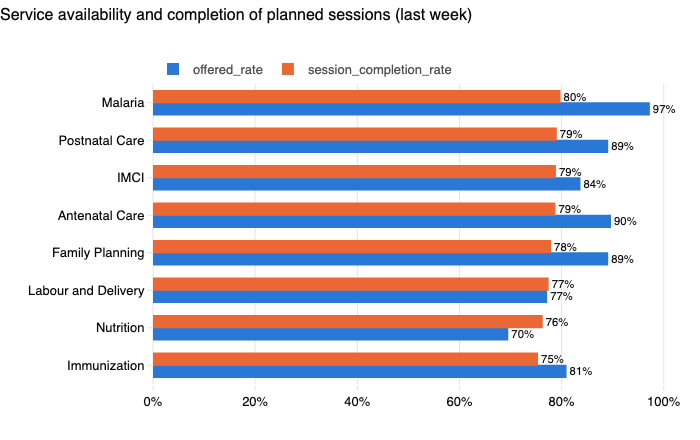

Malaria and ANC are near-universal, while Nutrition (69.6%) and Labour & Delivery are the least available. Planned sessions were fully delivered in 78.0% of service-weeks; Immunization has the lowest completion (75.4%).


In [13]:
r = q05(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q06. What stops planned sessions from happening?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [14]:
def q06(con):
    sql = """
    SELECT reason_not_conducted AS reason, COUNT(*) AS n
    FROM service_sessions WHERE all_conducted_flag=0 GROUP BY 1 ORDER BY n DESC"""
    df = q(con, sql); df["share"] = df.n / df.n.sum()
    fig = hbar(df, "share", "reason", "Why planned sessions were missed", xlabel="Share of missed-session reports")
    top = df.iloc[0]
    ans = (f"'{top.reason}' explains {pct(top.share)} of missed sessions - a human-resource problem before a supply problem. "
           f"Security concerns account for {pct(df.loc[df.reason.str.startswith('Security'),'share'].sum())} and vaccine or cold-chain issues for "
           f"{pct(df.loc[df.reason.isin(['Vaccine stock-out','Cold chain equipment failure']),'share'].sum())}.")
    return Result("Q06", "Service delivery", "What stops planned sessions from happening?", sql, df, ans, fig)

,reason,n,share
0,"Staff unavailable (leave, redeployment, strike)",535,0.326
1,"Attending training, meeting, or other official...",245,0.149
2,"Facility closed (holiday, strike, renovation)",199,0.121
3,Low community turnout / community resistance,168,0.103
4,"Security concerns (insecurity, movement restri...",167,0.102
5,Lack of transportation or logistics support,104,0.063
6,Weather or environmental conditions,97,0.059
7,Other,48,0.029
8,Vaccine stock-out,46,0.028
9,Cold chain equipment failure,30,0.018


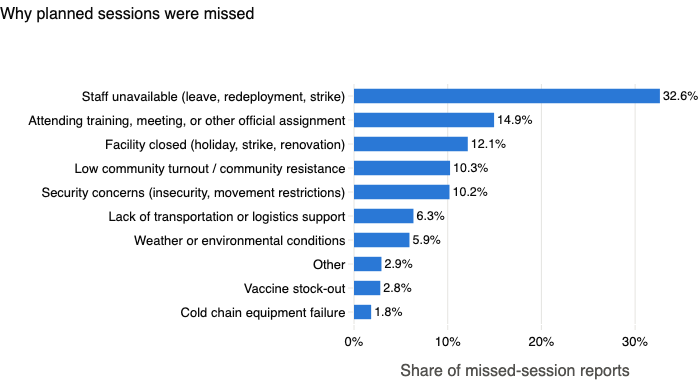

'Staff unavailable (leave, redeployment, strike)' explains 32.6% of missed sessions - a human-resource problem before a supply problem. Security concerns account for 10.2% and vaccine or cold-chain issues for 4.6%.


In [15]:
r = q06(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q07. What is training coverage across the network?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [16]:
def q07(con):
    sql = """
    SELECT t.training, COUNT(DISTINCT t.facility_id)*1.0/(SELECT COUNT(*) FROM facilities) AS coverage
    FROM trainings t GROUP BY 1 ORDER BY coverage DESC"""
    df = q(con, sql)
    trained = q(con, "SELECT AVG(staff_trained_past_2_years_flag) r FROM v_visits WHERE round_number=1").iloc[0].r
    fig = hbar(df, "coverage", "training", "Facilities with staff trained in the past 2 years, by training type", xlabel="Share of facilities")
    ans = (f"{pct(trained)} of facilities had any staff trained in the past two years. Coverage is highest for {df.iloc[0].training} ({pct(df.iloc[0].coverage)}) "
           f"and lowest for {df.iloc[-1].training} ({pct(df.iloc[-1].coverage)}); no single training reaches half of facilities.")
    return Result("Q07", "Service delivery", "What is training coverage across the network?", sql, df, ans, fig, key_numbers={"any_training_rate": float(trained)})

,training,coverage
0,Life Saving Skills,0.283
1,Postpartum Family Planning,0.266
2,"New Vaccine Introduction (HPV, MR)",0.261
3,Malaria Case Management,0.255
4,Data Management (DHIS2),0.250
5,Basic Emergency Obstetric and Newborn Care,0.234
6,Infection Prevention and Control,0.217
7,IMCI,0.217
8,Vaccine Management,0.212
9,Modified Life Saving Skills,0.207


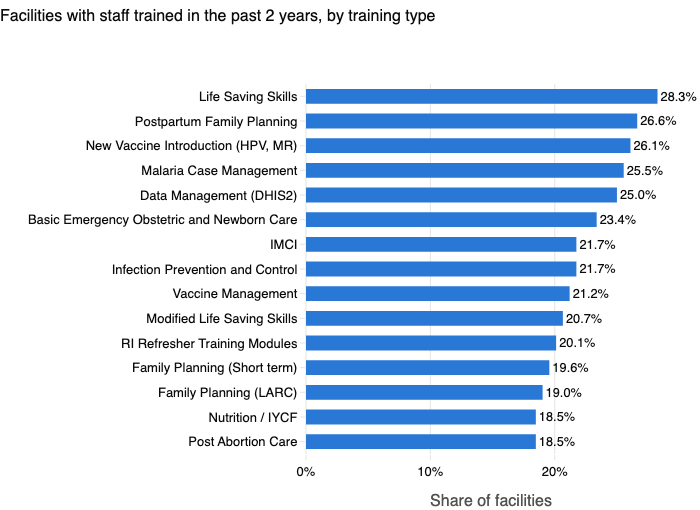

77.2% of facilities had any staff trained in the past two years. Coverage is highest for Life Saving Skills (28.3%) and lowest for Nutrition / IYCF (18.5%); no single training reaches half of facilities.


In [17]:
r = q07(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

---
# Human resources

## Q08. What does the workforce look like by cadre and employment type?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [18]:
def q08(con):
    sql = """
    SELECT cadre, SUM(permanent) AS permanent, SUM(adhoc_a) AS adhoc_a, SUM(adhoc_b) AS adhoc_b, SUM(volunteer) AS volunteer
    FROM v_staffing WHERE round_number=1 GROUP BY cadre ORDER BY permanent DESC"""
    df = q(con, sql)
    long = df.melt(id_vars="cadre", var_name="employment", value_name="headcount")
    fig = px.bar(long, x="headcount", y="cadre", color="employment", orientation="h", title="Workforce composition by cadre (baseline headcount)",
                 color_discrete_sequence=T.SERIES)
    fig.update_traces(marker_line_color="#fff", marker_line_width=2, width=0.6)
    fig.update_layout(yaxis=dict(categoryorder="total ascending"), xaxis_title="Health workers", yaxis_title="", legend_title="", height=440)
    tot = df[["permanent", "adhoc_a", "adhoc_b", "volunteer"]].sum()
    gender = q(con, "SELECT SUM(male_health_workers) m, SUM(female_health_workers) f FROM v_visits WHERE round_number=1").iloc[0]
    nodoc = q(con, "SELECT AVG(doctors=0) r FROM v_visits WHERE round_number=1 AND facility_type='Primary Health Centre'").iloc[0].r
    nonurse = q(con, "SELECT AVG(nurses_midwives=0) r FROM v_visits WHERE round_number=1 AND facility_type IN ('Primary Health Centre','Basic Health Centre')").iloc[0].r
    ans = (f"The network has {int(tot.sum()):,} health workers: {pct(tot.permanent/tot.sum())} permanent, {pct((tot.adhoc_a+tot.adhoc_b)/tot.sum())} ad hoc/seconded and {pct(tot.volunteer/tot.sum())} volunteers. "
           f"CHEWs and JCHEWs form the backbone; {pct(nodoc)} of PHCs have no permanent doctor and {pct(nonurse)} of PHCs/BHCs have no permanent nurse or midwife. "
           f"Women make up {pct(gender.f/(gender.m+gender.f))} of the workforce.")
    return Result("Q08", "Human resources", "What does the workforce look like by cadre and employment type?", sql, df, ans, fig,
                  key_numbers={"health_workers": int(tot.sum()), "phc_without_doctor": float(nodoc), "phc_bhc_without_nurse": float(nonurse)})

,cadre,permanent,adhoc_a,adhoc_b,volunteer
0,Nurse/Midwife,762,190,83,15
1,CHEW,691,156,66,177
2,JCHEW,467,125,74,162
3,Medical Lab Technician,238,16,70,19
4,CHO,236,54,0,23
5,Medical Officer,195,11,0,22
6,Pharmacy Technician,190,14,76,16
7,Medical Records Officer,172,17,0,186
8,Environmental Health Officer,93,13,0,23


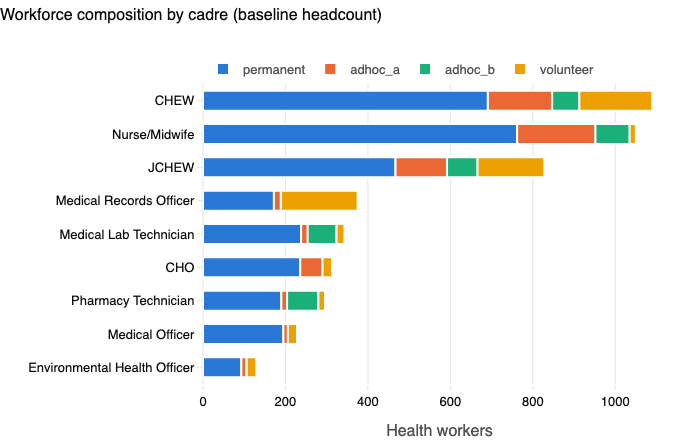

The network has 4,652 health workers: 65.4% permanent, 20.7% ad hoc/seconded and 13.8% volunteers. CHEWs and JCHEWs form the backbone; 38.1% of PHCs have no permanent doctor and 9.1% of PHCs/BHCs have no permanent nurse or midwife. Women make up 55.1% of the workforce.


In [19]:
r = q08(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q09. How high is absenteeism, and which cadres are most affected?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [20]:
def q09(con):
    sql = """
    SELECT cadre, SUM(permanent_present_today)*1.0/SUM(permanent_scheduled_today) AS attendance_rate, SUM(permanent_scheduled_today) AS scheduled
    FROM v_staffing WHERE permanent_scheduled_today>0 GROUP BY cadre ORDER BY attendance_rate"""
    df = q(con, sql)
    fig = hbar(df, "attendance_rate", "cadre", "Attendance rate of permanent staff scheduled for duty, by cadre", xlabel="Present / scheduled")
    overall = q(con, "SELECT SUM(permanent_present_today)*1.0/SUM(permanent_scheduled_today) r FROM staffing_by_cadre").iloc[0].r
    fig.add_vline(x=overall, line_dash="dot", line_color=T.TEXT_SECONDARY, annotation_text=f"Overall {pct(overall)}")
    ans = (f"Across all visits, {pct(overall)} of permanent staff scheduled for duty were actually present - an absenteeism rate of {pct(1-overall)}. "
           f"{df.iloc[0].cadre}s are least reliably present ({pct(df.iloc[0].attendance_rate)}); {df.iloc[-1].cadre}s most ({pct(df.iloc[-1].attendance_rate)}).")
    return Result("Q09", "Human resources", "How high is absenteeism, and which cadres are most affected?", sql, df, ans, fig, key_numbers={"attendance_rate": float(overall)})

,cadre,attendance_rate,scheduled
0,JCHEW,0.686,2461
1,CHO,0.704,1252
2,CHEW,0.713,3649
3,Medical Records Officer,0.724,881
4,Environmental Health Officer,0.727,476
5,Nurse/Midwife,0.732,3996
6,Medical Officer,0.735,1017
7,Medical Lab Technician,0.737,1260
8,Pharmacy Technician,0.758,987


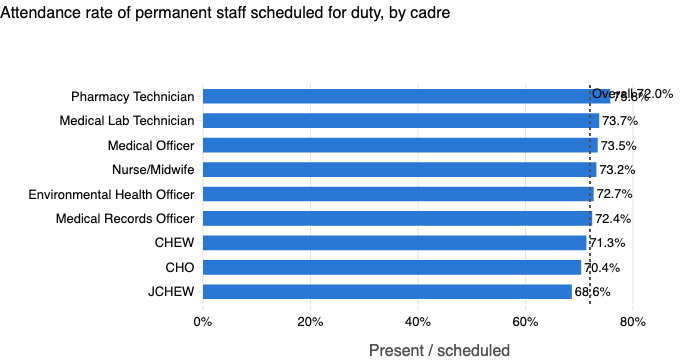

Across all visits, 72.0% of permanent staff scheduled for duty were actually present - an absenteeism rate of 28.0%. JCHEWs are least reliably present (68.6%); Pharmacy Technicians most (75.8%).


In [21]:
r = q09(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q10. Where is absenteeism geographically concentrated?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [22]:
def q10(con):
    sql = """
    SELECT lga, SUM(permanent_present_today)*1.0/SUM(permanent_scheduled_today) AS attendance_rate
    FROM v_staffing WHERE permanent_scheduled_today>0 GROUP BY lga ORDER BY attendance_rate"""
    df = q(con, sql)
    fig = hbar(df, "attendance_rate", "lga", "Permanent staff attendance rate by LGA", xlabel="Present / scheduled")
    ans = (f"Attendance ranges from {pct(df.iloc[0].attendance_rate)} in {df.iloc[0].lga} to {pct(df.iloc[-1].attendance_rate)} in {df.iloc[-1].lga} - "
           f"a {100*(df.iloc[-1].attendance_rate-df.iloc[0].attendance_rate):.0f}-point spread that points to LGA-level management and security effects rather than individual behaviour.")
    return Result("Q10", "Human resources", "Where is absenteeism geographically concentrated?", sql, df, ans, fig)

,lga,attendance_rate
0,Igabi,0.576
1,Giwa,0.627
2,Kubau,0.642
3,Chikun,0.666
4,Kauru,0.674
5,Makarfi,0.686
6,Kudan,0.698
7,Kachia,0.701
8,Ikara,0.707
9,Kajuru,0.715


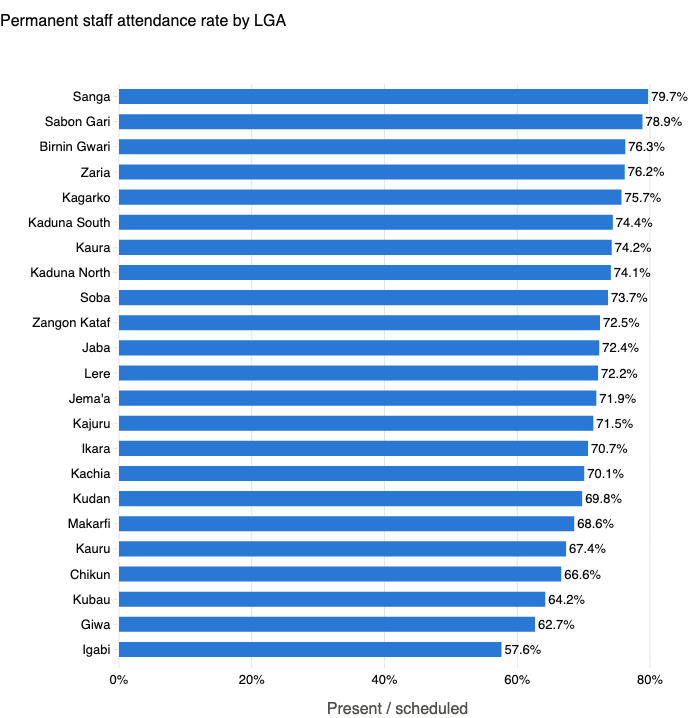

Attendance ranges from 57.6% in Igabi to 79.7% in Sanga - a 22-point spread that points to LGA-level management and security effects rather than individual behaviour.


In [23]:
r = q10(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q11. Why are staff absent?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [24]:
def q11(con):
    sql = """
    SELECT reason, SUM(staff_count) AS staff FROM v_absence GROUP BY reason ORDER BY staff DESC"""
    df = q(con, sql); df["share"] = df.staff / df.staff.sum()
    fig = hbar(df.head(12), "share", "reason", "Top reasons permanent staff were absent (share of absent staff)", xlabel="Share of absences")
    salary_related = df.loc[df.reason.isin(["Access to Salary", "Dissatisfaction with Salary and Benefits"]), "share"].sum()
    ans = (f"'{df.iloc[0].reason}' is the top recorded reason ({pct(df.iloc[0].share)}), followed by '{df.iloc[1].reason}' ({pct(df.iloc[1].share)}). "
           f"Salary-linked absence (going to access salary, or dissatisfaction with pay) accounts for {pct(salary_related)} of all absences and is directly addressable by payment reform.")
    return Result("Q11", "Human resources", "Why are staff absent?", sql, df, ans, fig, key_numbers={"salary_related_absence_share": float(salary_related)})

,reason,staff,share
0,"Leave (Study, Annual, Maternity, etc.)",501,0.112
1,Access to Salary,403,0.090
2,Personal Health Issues,375,0.084
3,Shift,364,0.081
4,Long Distance to Workplace,337,0.075
5,Transportation Problems,324,0.072
6,Workshop and Training,317,0.071
7,Family Responsibilities,307,0.069
8,Dissatisfaction with Salary and Benefits,286,0.064
9,Meetings,265,0.059


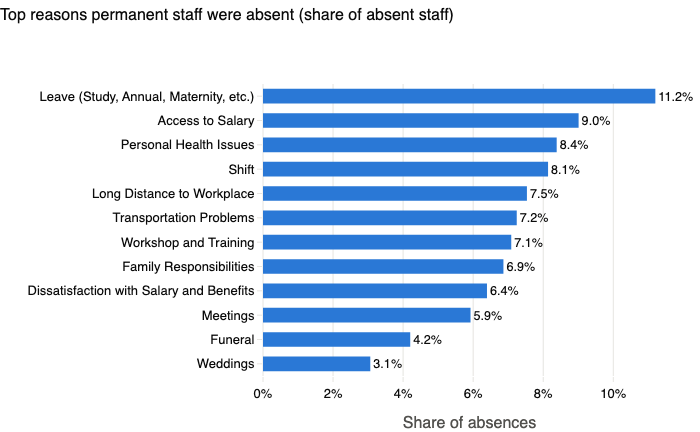

'Leave (Study, Annual, Maternity, etc.)' is the top recorded reason (11.2%), followed by 'Access to Salary' (9.0%). Salary-linked absence (going to access salary, or dissatisfaction with pay) accounts for 15.4% of all absences and is directly addressable by payment reform.


In [25]:
r = q11(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q12. How do salary delays affect attendance and service delivery over time?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [26]:
def q12(con):
    sql = """
    SELECT round_number, round_name,
           AVG(salary_paid_on_time_last_3_months_flag) AS salary_on_time,
           SUM(permanent_present_today)*1.0/SUM(permanent_scheduled_today) AS attendance_rate,
           AVG(session_completion_rate) AS session_completion
    FROM v_visits GROUP BY 1,2 ORDER BY 1"""
    df = q(con, sql)
    fig = go.Figure()
    for col, name in [("salary_on_time", "Salary paid on time"), ("attendance_rate", "Staff attendance"), ("session_completion", "Sessions completed")]:
        fig.add_trace(go.Scatter(x=df.round_name, y=df[col], mode="lines+markers", name=name, line=dict(width=2), marker=dict(size=9)))
    fig.update_layout(title="Salary timeliness, attendance and session completion by visit round", yaxis_tickformat=".0%", xaxis_title="", yaxis_title="", hovermode="x unified")
    shock = df.loc[df.salary_on_time.idxmin()]
    normal = df[df.round_number != shock.round_number]
    ans = (f"In {shock.round_name} salary timeliness collapsed to {pct(shock.salary_on_time)} (vs {pct(normal.salary_on_time.mean())} in other rounds); "
           f"attendance fell to {pct(shock.attendance_rate)} (vs {pct(normal.attendance_rate.mean())}) and session completion to {pct(shock.session_completion)} in the same round. "
           f"Late salaries translate almost immediately into empty duty posts.")
    return Result("Q12", "Human resources", "How do salary delays affect attendance and service delivery over time?", sql, df, ans, fig)

,round_number,round_name,salary_on_time,attendance_rate,session_completion
0,1,Baseline,0.799,0.745,0.773
1,2,Bi-weekly 1,0.848,0.751,0.817
2,3,Bi-weekly 2,0.728,0.723,0.785
3,4,Bi-weekly 3,0.141,0.637,0.710
4,5,Bi-weekly 4,0.815,0.739,0.805
5,6,Bi-weekly 5,0.755,0.725,0.788


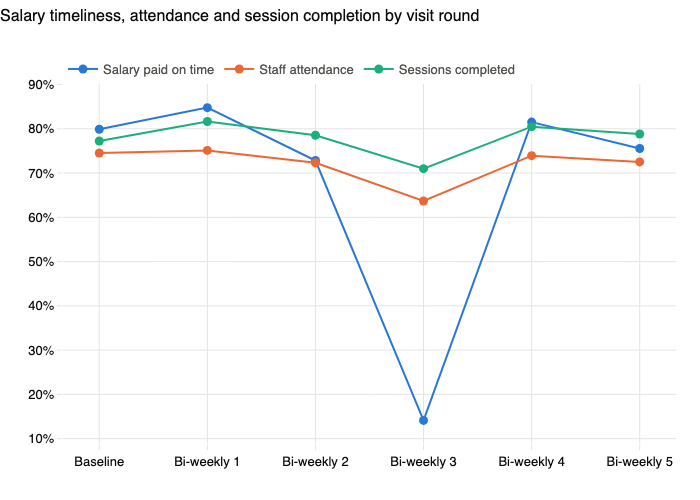

In Bi-weekly 3 salary timeliness collapsed to 14.1% (vs 78.9% in other rounds); attendance fell to 63.7% (vs 73.7%) and session completion to 71.0% in the same round. Late salaries translate almost immediately into empty duty posts.


In [27]:
r = q12(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q13. Do roster practices and salary timeliness independently predict attendance?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [28]:
def q13(con):
    sql = """
    SELECT CASE WHEN salary_paid_on_time_last_3_months_flag=1 THEN 'Salary on time' ELSE 'Salary delayed' END AS salary,
           CASE WHEN roster_updated_this_week_flag=1 THEN 'Roster updated' ELSE 'Roster not updated' END AS roster,
           SUM(permanent_present_today)*1.0/SUM(permanent_scheduled_today) AS attendance_rate, COUNT(*) AS visits
    FROM v_visits GROUP BY 1,2"""
    df = q(con, sql)
    fig = px.bar(df, x="salary", y="attendance_rate", color="roster", barmode="group", text="attendance_rate",
                 title="Attendance by salary timeliness and roster practice", color_discrete_sequence=T.SERIES)
    fig.update_traces(texttemplate="%{text:.1%}", textposition="outside", width=0.3)
    fig.update_layout(yaxis_tickformat=".0%", xaxis_title="", yaxis_title="Attendance rate", legend_title="", yaxis_range=[0, 1])
    piv = df.pivot(index="salary", columns="roster", values="attendance_rate")
    ans = (f"When salary is on time and the roster was updated this week, attendance is {pct(piv.loc['Salary on time','Roster updated'])}; "
           f"with delayed salary and a stale roster it drops to {pct(piv.loc['Salary delayed','Roster not updated'])}. "
           f"Both levers matter, and roster discipline partly cushions the salary effect.")
    return Result("Q13", "Human resources", "Do roster practices and salary timeliness independently predict attendance?", sql, df, ans, fig)

,salary,roster,attendance_rate,visits
0,Salary delayed,Roster not updated,0.550,188
1,Salary delayed,Roster updated,0.671,164
2,Salary on time,Roster not updated,0.703,374
3,Salary on time,Roster updated,0.805,378


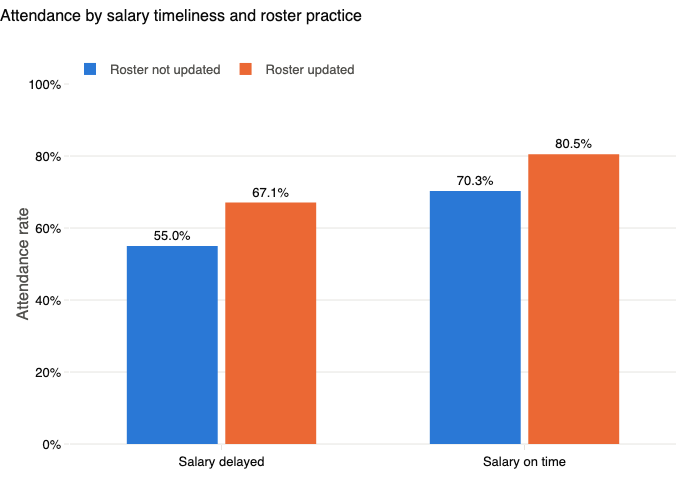

When salary is on time and the roster was updated this week, attendance is 80.5%; with delayed salary and a stale roster it drops to 55.0%. Both levers matter, and roster discipline partly cushions the salary effect.


In [29]:
r = q13(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q14. How much service time is lost to accessing salary payments?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [30]:
def q14(con):
    sql = """
    SELECT staff_leave_facility_for_salary_frequency AS frequency, urban_rural, COUNT(*) AS visits
    FROM v_visits GROUP BY 1,2"""
    df = q(con, sql); df["share"] = df.visits / df.groupby("urban_rural").visits.transform("sum")
    fig = px.bar(df, x="frequency", y="share", color="urban_rural", barmode="group", text="share",
                 category_orders={"frequency": C.LEAVE_FOR_SALARY_FREQ}, title="How often staff leave the facility to access their salary",
                 color_discrete_sequence=T.SERIES)
    fig.update_traces(texttemplate="%{text:.0%}", textposition="outside", width=0.3)
    fig.update_layout(yaxis_tickformat=".0%", xaxis_title="", yaxis_title="Share of visits", legend_title="")
    reason = q(con, "SELECT leave_for_salary_reason r, COUNT(*) n FROM v_visits WHERE leave_for_salary_reason IS NOT NULL GROUP BY 1 ORDER BY n DESC").iloc[0]
    rural_freq = df[(df.urban_rural == "Rural") & df.frequency.isin(["2-3 times a month", "Weekly"])].share.sum()
    ans = (f"In rural facilities, staff leave the post to access salary two or more times a month in {pct(rural_freq)} of visits; the main reason is '{reason.r}'. "
           f"Bringing agent banking or POS access to facility catchments would recover many lost duty days.")
    return Result("Q14", "Human resources", "How much service time is lost to accessing salary payments?", sql, df, ans, fig)

,frequency,urban_rural,visits,share
0,2-3 times a month,Rural,272,0.296
1,2-3 times a month,Urban,52,0.280
2,Never,Rural,106,0.115
3,Never,Urban,51,0.274
4,Once a month,Rural,361,0.393
5,Once a month,Urban,83,0.446
6,Weekly,Rural,179,0.195


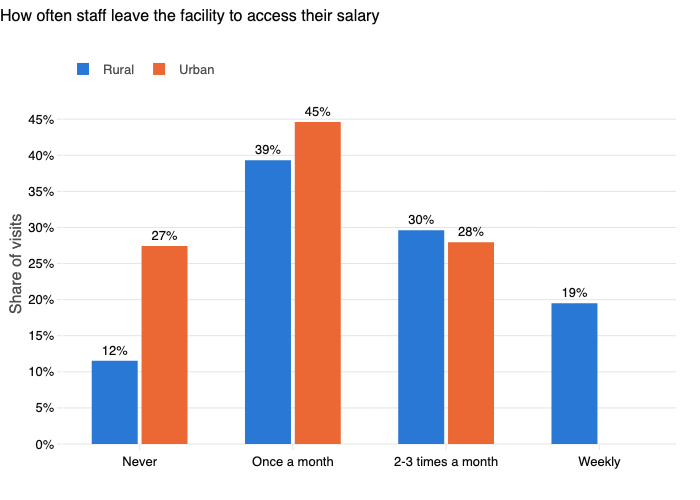

In rural facilities, staff leave the post to access salary two or more times a month in 49.1% of visits; the main reason is 'No bank or ATM nearby'. Bringing agent banking or POS access to facility catchments would recover many lost duty days.


In [31]:
r = q14(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

---
# Supply chain

## Q15. Which essential medicines and commodities are most often stocked out?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [32]:
def q15(con):
    sql = """
    SELECT commodity, category, AVG(stockout_flag) AS stockout_rate, AVG(zero_balance_flag) AS zero_balance_rate,
           AVG(below_min_stock_flag) AS below_min_rate, COUNT(*) AS observations
    FROM v_commodity WHERE stocked_flag=1 GROUP BY 1,2 ORDER BY stockout_rate DESC"""
    df = q(con, sql)
    fig = hbar(df, "stockout_rate", "commodity", "Stock-out rate since last visit, by tracer commodity", color="category", xlabel="Share of visits with a stock-out")
    fig.update_layout(legend_title="")
    overall = q(con, "SELECT AVG(stockout_flag) r FROM commodity_stock WHERE stocked_flag=1").iloc[0].r
    mat = df[df.category == "Maternal"].stockout_rate.mean()
    ans = (f"On average {pct(overall)} of stocked tracer items had a stock-out since the previous visit. Maternal life-saving commodities fare worst "
           f"(mean {pct(mat)}): {df.iloc[0].commodity} ({pct(df.iloc[0].stockout_rate)}), {df.iloc[1].commodity} ({pct(df.iloc[1].stockout_rate)}) and {df.iloc[2].commodity} ({pct(df.iloc[2].stockout_rate)}). "
           f"{df.iloc[-1].commodity} is the most reliably available ({pct(df.iloc[-1].stockout_rate)}).")
    return Result("Q15", "Supply chain", "Which essential medicines and commodities are most often stocked out?", sql, df, ans, fig,
                  key_numbers={"overall_stockout_rate": float(overall), "maternal_stockout_rate": float(mat)})

,commodity,category,stockout_rate,zero_balance_rate,below_min_rate,observations
0,Calibrated Blood Collection Drape,Maternal,0.554,0.582,0.958,852
1,Magnesium Sulphate Injection,Maternal,0.427,0.453,0.911,852
2,Tranexamic Acid Injection,Maternal,0.426,0.477,0.918,852
3,Implants,Family Planning,0.403,0.440,0.912,984
4,Chlorhexidine Gel,Child,0.387,0.414,0.932,1104
5,Ibuprofen Suspension,Child,0.374,0.390,0.859,1104
6,Misoprostol,Maternal,0.351,0.353,0.857,852
7,Artemether Injection,General,0.329,0.341,0.880,1104
8,Ferrous Sulphate,Maternal,0.317,0.318,0.847,1104
9,Zinc,Child,0.302,0.305,0.823,1104


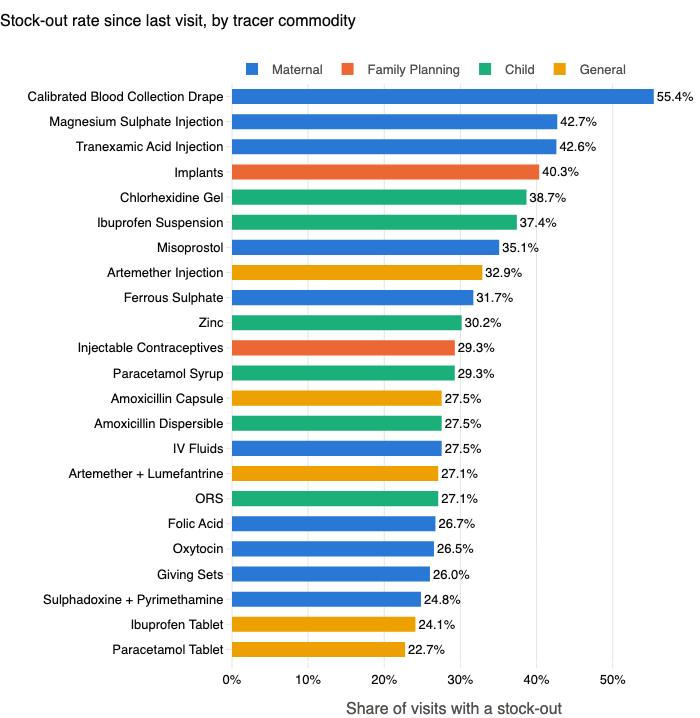

On average 31.4% of stocked tracer items had a stock-out since the previous visit. Maternal life-saving commodities fare worst (mean 33.9%): Calibrated Blood Collection Drape (55.4%), Magnesium Sulphate Injection (42.7%) and Tranexamic Acid Injection (42.6%). Paracetamol Tablet is the most reliably available (22.7%).


In [33]:
r = q15(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q16. Are stock-outs caused upstream or at the facility?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [34]:
def q16(con):
    sql = """
    SELECT stockout_reason AS reason, COUNT(*) AS n FROM commodity_stock WHERE stockout_flag=1 GROUP BY 1 ORDER BY n DESC"""
    df = q(con, sql); df["share"] = df.n / df.n.sum()
    fig = hbar(df, "share", "reason", "Main reasons for stock-outs", xlabel="Share of stock-out events")
    upstream = df.loc[df.reason.isin(["Stock-out at LGA/state/central supply level", "Delay in delivery or distribution", "Incomplete fulfillment of requisition", "No feedback from KADHSMA"]), "share"].sum()
    facility = df.loc[df.reason.isin(["Requisition not submitted or submitted late", "Poor quantification or forecasting", "Expired or damaged stock not replaced"]), "share"].sum()
    ans = (f"{pct(upstream)} of stock-outs are attributed to upstream causes (central stock-out, delivery delay, partial fulfilment, no feedback), versus {pct(facility)} to facility-side causes "
           f"(late requisition, poor forecasting, unreplaced expiries). The single largest is '{df.iloc[0].reason}' at {pct(df.iloc[0].share)}.")
    return Result("Q16", "Supply chain", "Are stock-outs caused upstream or at the facility?", sql, df, ans, fig,
                  key_numbers={"upstream_share": float(upstream), "facility_share": float(facility)})

,reason,n,share
0,Stock-out at LGA/state/central supply level,2323,0.310
1,Delay in delivery or distribution,1211,0.161
2,Requisition not submitted or submitted late,731,0.097
3,High demand or unexpected increase in consumption,652,0.087
4,Poor quantification or forecasting,552,0.074
5,Insufficient funds for procurement,533,0.071
6,Incomplete fulfillment of requisition,444,0.059
7,No feedback from KADHSMA,393,0.052
8,Expired or damaged stock not replaced,265,0.035
9,Other,199,0.027


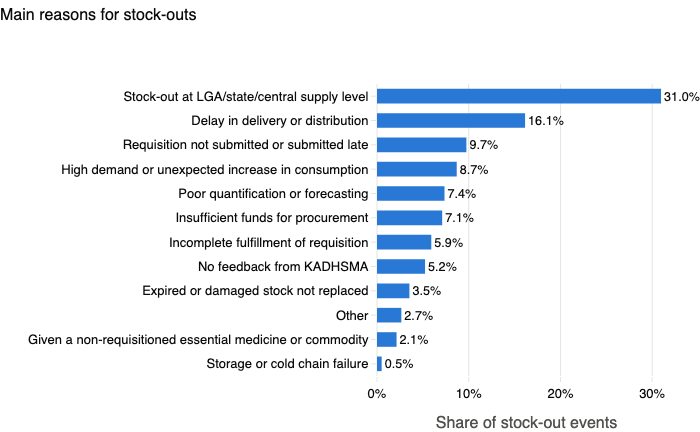

58.3% of stock-outs are attributed to upstream causes (central stock-out, delivery delay, partial fulfilment, no feedback), versus 20.6% to facility-side causes (late requisition, poor forecasting, unreplaced expiries). The single largest is 'Stock-out at LGA/state/central supply level' at 31.0%.


In [35]:
r = q16(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q17. Which LGAs have the worst commodity availability?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [36]:
def q17(con):
    sql = """
    SELECT lga, AVG(stockout_flag) AS stockout_rate FROM v_commodity WHERE stocked_flag=1 GROUP BY lga ORDER BY stockout_rate DESC"""
    df = q(con, sql)
    fig = hbar(df, "stockout_rate", "lga", "Tracer commodity stock-out rate by LGA", xlabel="Share of stocked items with a stock-out")
    ans = (f"Stock-out rates range from {pct(df.iloc[-1].stockout_rate)} in {df.iloc[-1].lga} to {pct(df.iloc[0].stockout_rate)} in {df.iloc[0].lga}. "
           f"The top-five LGAs ({', '.join(df.head(5).lga)}) should be prioritised for supply-chain supervision.")
    return Result("Q17", "Supply chain", "Which LGAs have the worst commodity availability?", sql, df, ans, fig)

,lga,stockout_rate
0,Kauru,0.422
1,Chikun,0.406
2,Kudan,0.406
3,Igabi,0.374
4,Giwa,0.367
5,Jema'a,0.362
6,Lere,0.359
7,Kajuru,0.343
8,Kaduna South,0.342
9,Zaria,0.337


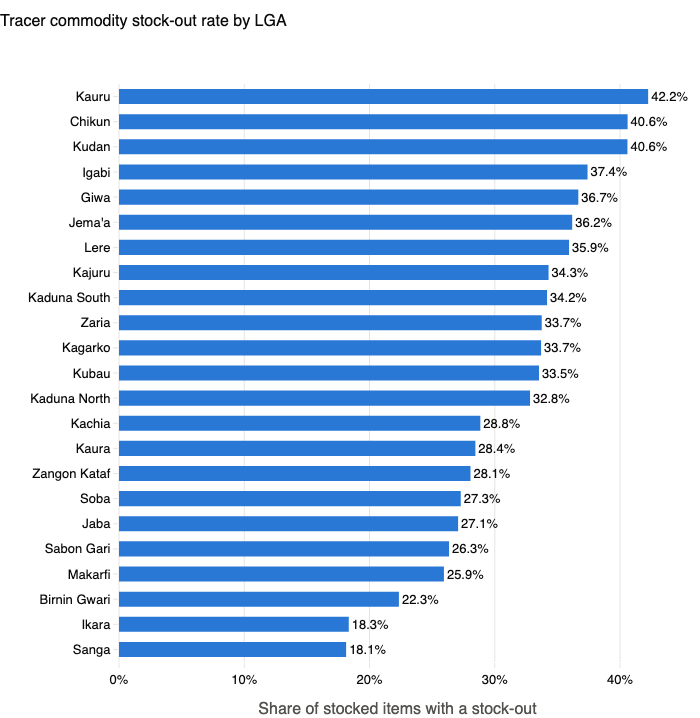

Stock-out rates range from 18.1% in Sanga to 42.2% in Kauru. The top-five LGAs (Kauru, Chikun, Kudan, Igabi, Giwa) should be prioritised for supply-chain supervision.


In [37]:
r = q17(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q18. How well does the requisition-to-delivery process work?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [38]:
def q18(con):
    sql = """
    SELECT requisition_frequency, AVG(requisition_submitted_last_cycle_flag) AS submitted,
           AVG(requisition_complete_on_time_flag) AS complete_on_time,
           AVG(CASE WHEN requisition_receipt_status='Yes, all items received' THEN 1.0 WHEN requisition_receipt_status IS NULL THEN NULL ELSE 0 END) AS fully_received,
           AVG(delivery_documentation_provided_flag) AS documented, COUNT(*) AS visits
    FROM v_visits GROUP BY 1 ORDER BY visits DESC"""
    df = q(con, sql)
    long = df.melt(id_vars=["requisition_frequency", "visits"], var_name="stage", value_name="rate").dropna()
    fig = px.bar(long, x="stage", y="rate", color="requisition_frequency", barmode="group", text="rate",
                 title="Requisition funnel: submitted, complete & on time, fully received, documented", color_discrete_sequence=T.SERIES,
                 category_orders={"stage": ["submitted", "complete_on_time", "fully_received", "documented"]})
    fig.update_traces(texttemplate="%{text:.0%}", textposition="outside", width=0.18)
    fig.update_layout(yaxis_tickformat=".0%", xaxis_title="", yaxis_title="", legend_title="Requisition frequency")
    o = q(con, """SELECT AVG(requisition_submitted_last_cycle_flag) s, AVG(requisition_complete_on_time_flag) c,
                  AVG(CASE WHEN requisition_receipt_status='Yes, all items received' THEN 1.0 WHEN requisition_receipt_status IS NULL THEN NULL ELSE 0 END) f,
                  AVG(delivery_documentation_provided_flag) d FROM v_visits""").iloc[0]
    ans = (f"Only {pct(o.s)} of facilities submitted a requisition in the last cycle; of those, {pct(o.c)} were complete and on time and {pct(o.f)} were fully filled. "
           f"Delivery documentation accompanied {pct(o.d)} of receipts. Each leak in this funnel compounds into the stock-out rates above.")
    return Result("Q18", "Supply chain", "How well does the requisition-to-delivery process work?", sql, df, ans, fig,
                  key_numbers={"requisition_submitted": float(o.s), "complete_on_time": float(o.c), "fully_received": float(o.f)})

,requisition_frequency,submitted,complete_on_time,fully_received,documented,visits
0,Monthly,0.705,0.714,0.475,0.789,624
1,Bi-monthly,0.725,0.696,0.497,0.832,222
2,We do not submit requisitions,0.000,NaN,NaN,NaN,150
3,Quarterly,0.741,0.750,0.550,0.739,108


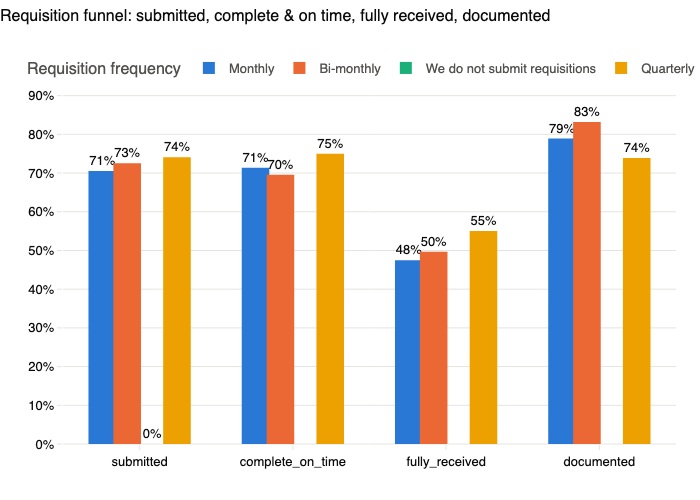

Only 61.7% of facilities submitted a requisition in the last cycle; of those, 71.4% were complete and on time and 48.9% were fully filled. Delivery documentation accompanied 79.4% of receipts. Each leak in this funnel compounds into the stock-out rates above.


In [39]:
r = q18(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q19. Do requisition discipline and stock-management skills reduce stock-outs?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [40]:
def q19(con):
    sql = """
    SELECT CASE WHEN requisition_submitted_last_cycle_flag=1 THEN 'Requisition submitted' ELSE 'No requisition' END AS requisition,
           knows_min_stock_calculation, AVG(stockout_flag) AS stockout_rate, COUNT(*) AS n
    FROM v_commodity WHERE stocked_flag=1 GROUP BY 1,2"""
    df = q(con, sql)
    fig = px.bar(df, x="knows_min_stock_calculation", y="stockout_rate", color="requisition", barmode="group", text="stockout_rate",
                 title="Stock-out rate by requisition behaviour and minimum-stock knowledge", color_discrete_sequence=T.SERIES)
    fig.update_traces(texttemplate="%{text:.1%}", textposition="outside", width=0.3)
    fig.update_layout(yaxis_tickformat=".0%", xaxis_title="Knows how to calculate minimum stock", yaxis_title="Stock-out rate", legend_title="")
    best = df.loc[df.stockout_rate.idxmin()]; worst = df.loc[df.stockout_rate.idxmax()]
    ans = (f"Facilities that submitted a requisition and know how to calculate minimum stock have a {pct(best.stockout_rate)} stock-out rate, against {pct(worst.stockout_rate)} where "
           f"no requisition was submitted and nobody can calculate minimum stock. Requisition discipline and LMIS skills are the cheapest stock-out reducers available.")
    return Result("Q19", "Supply chain", "Do requisition discipline and stock-management skills reduce stock-outs?", sql, df, ans, fig)

,requisition,knows_min_stock_calculation,stockout_rate,n
0,No requisition,No,0.428,2617
1,No requisition,"Yes, I know how to calculate",0.435,4308
2,No requisition,"Yes, someone else is assigned to calculate",0.411,2215
3,Requisition submitted,No,0.259,4805
4,Requisition submitted,"Yes, I know how to calculate",0.237,6672
5,Requisition submitted,"Yes, someone else is assigned to calculate",0.236,3275


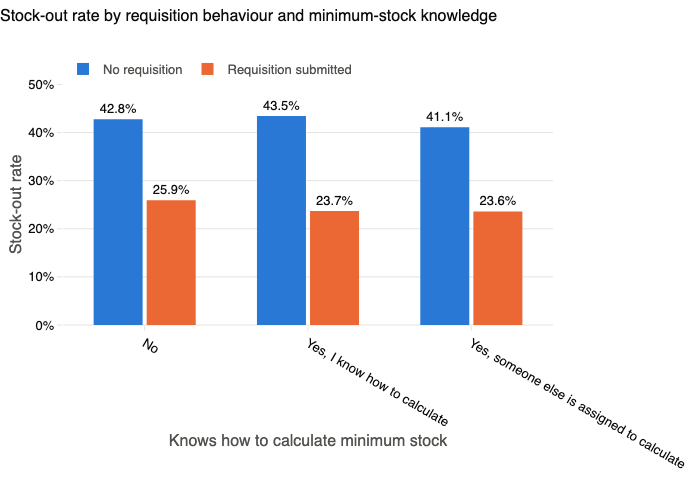

Facilities that submitted a requisition and know how to calculate minimum stock have a 23.6% stock-out rate, against 43.5% where no requisition was submitted and nobody can calculate minimum stock. Requisition discipline and LMIS skills are the cheapest stock-out reducers available.


In [41]:
r = q19(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q20. Which supply sources are most reliable?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [42]:
def q20(con):
    sql = """
    SELECT supplier, AVG(stockout_flag) AS stockout_rate, COUNT(*) AS n FROM commodity_stock WHERE stocked_flag=1 AND supplier IS NOT NULL GROUP BY 1 HAVING n>200 ORDER BY stockout_rate"""
    df = q(con, sql)
    fig = hbar(df, "stockout_rate", "supplier", "Stock-out rate by commodity supplier", xlabel="Share of items with a stock-out")
    share = q(con, "SELECT supplier, COUNT(*)*1.0/(SELECT COUNT(*) FROM commodity_stock WHERE supplier IS NOT NULL) s FROM commodity_stock WHERE supplier IS NOT NULL GROUP BY 1 ORDER BY s DESC").iloc[0]
    ans = (f"{share.supplier} supplies {pct(share.s)} of stocked items. Items sourced from {df.iloc[0].supplier} show the lowest stock-out rate ({pct(df.iloc[0].stockout_rate)}) "
           f"and {df.iloc[-1].supplier}-sourced items the highest ({pct(df.iloc[-1].stockout_rate)}).")
    return Result("Q20", "Supply chain", "Which supply sources are most reliable?", sql, df, ans, fig)

,supplier,stockout_rate,n
0,Open Market,0.246,3027
1,Zipline,0.249,2257
2,Free MNCH,0.301,3202
3,LGA,0.309,1350
4,Federal Government,0.320,2604
5,Donations,0.323,1026
6,KDHSMA,0.347,8748
7,NGO,0.365,1678


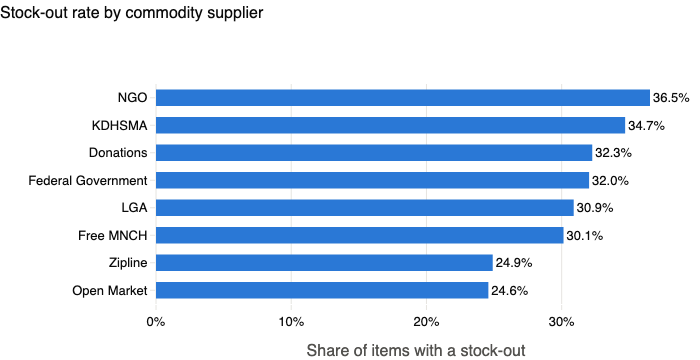

KDHSMA supplies 36.6% of stocked items. Items sourced from Open Market show the lowest stock-out rate (24.6%) and NGO-sourced items the highest (36.5%).


In [43]:
r = q20(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q21. How many facilities are below minimum stock (early-warning)?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [44]:
def q21(con):
    sql = """
    SELECT commodity, AVG(below_min_stock_flag) AS below_min_rate,
           AVG(CASE WHEN stock_adequacy_ratio IS NOT NULL THEN MIN(stock_adequacy_ratio, 5) END) AS median_adequacy
    FROM commodity_stock WHERE stocked_flag=1 AND minimum_stock_level IS NOT NULL GROUP BY 1 ORDER BY below_min_rate DESC"""
    df = q(con, sql)
    fig = hbar(df, "below_min_rate", "commodity", "Share of facilities holding less than their minimum stock level", xlabel="Below minimum stock")
    known = q(con, "SELECT AVG(minimum_stock_level IS NOT NULL) r FROM commodity_stock WHERE stocked_flag=1").iloc[0].r
    ans = (f"A minimum stock level was known for {pct(known)} of stocked items. Where known, {pct(df.below_min_rate.mean())} of items sit below the minimum - "
           f"the facility is one bad fortnight away from a stock-out. {df.iloc[0].commodity} ({pct(df.iloc[0].below_min_rate)}) is most exposed.")
    return Result("Q21", "Supply chain", "How many facilities are below minimum stock (early-warning)?", sql, df, ans, fig, key_numbers={"min_stock_known": float(known)})

,commodity,below_min_rate,median_adequacy
0,Calibrated Blood Collection Drape,0.958,0.201
1,Chlorhexidine Gel,0.932,0.299
2,Tranexamic Acid Injection,0.918,0.290
3,Implants,0.912,0.310
4,Magnesium Sulphate Injection,0.911,0.318
5,Artemether Injection,0.880,0.420
6,Ibuprofen Tablet,0.865,0.490
7,Ibuprofen Suspension,0.859,0.403
8,Misoprostol,0.857,0.421
9,Injectable Contraceptives,0.850,0.464


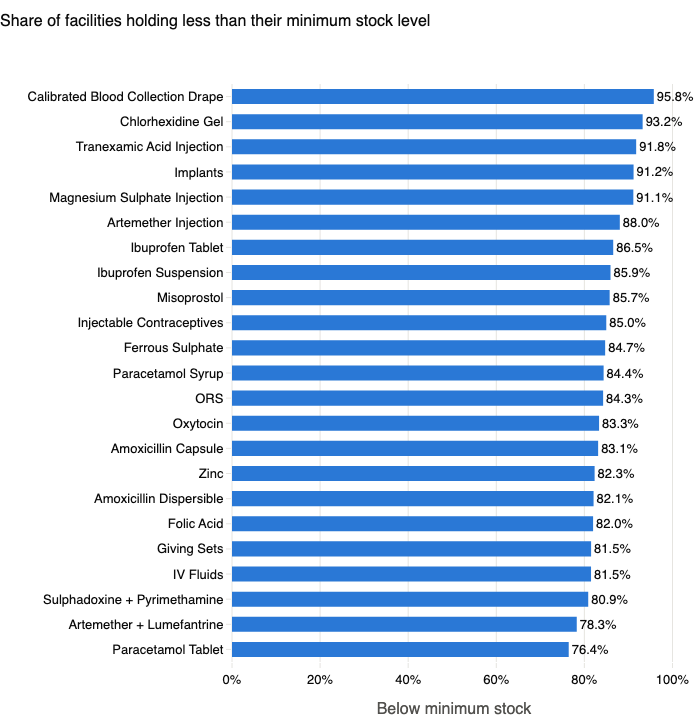

A minimum stock level was known for 78.4% of stocked items. Where known, 85.2% of items sit below the minimum - the facility is one bad fortnight away from a stock-out. Calibrated Blood Collection Drape (95.8%) is most exposed.


In [45]:
r = q21(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

---
# Vaccines

## Q22. Which vaccines are available, and where are the gaps?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [46]:
def q22(con):
    sql = """
    SELECT vaccine, AVG(in_stock_flag) AS in_stock_rate, SUM(doses_used) AS doses_used, AVG(physically_verified_flag) AS verified
    FROM vaccine_stock GROUP BY 1 ORDER BY in_stock_rate"""
    df = q(con, sql)
    fig = hbar(df, "in_stock_rate", "vaccine", "Vaccine availability at facilities that stock vaccines", xlabel="Share of visits with vaccine in stock")
    status = q(con, "SELECT vaccine_stock_status s, COUNT(DISTINCT facility_id) n FROM v_visits WHERE round_number=1 GROUP BY 1").set_index("s").n
    tot = status.sum()
    ans = (f"{pct(status.get('Yes',0)/tot)} of facilities stock vaccines on site, {pct(status.get(C.VACCINE_STOCK_STATUS[1],0)/tot)} immunise without stocking and "
           f"{pct(status.get(C.VACCINE_STOCK_STATUS[2],0)/tot)} offer no immunisation. Among stocking facilities, availability is lowest for {df.iloc[0].vaccine} ({pct(df.iloc[0].in_stock_rate)}) "
           f"and {df.iloc[1].vaccine} ({pct(df.iloc[1].in_stock_rate)}) - the newer antigens - and highest for {df.iloc[-1].vaccine} ({pct(df.iloc[-1].in_stock_rate)}).")
    return Result("Q22", "Vaccines", "Which vaccines are available, and where are the gaps?", sql, df, ans, fig)

,vaccine,in_stock_rate,doses_used,verified
0,HPV,0.556,6688,0.510
1,MEN A,0.587,6808,0.543
2,MR,0.597,7772,0.555
3,BCG,0.690,12143,0.636
4,IPV,0.703,13548,0.648
5,PENTA,0.714,26815,0.658
6,PCV,0.725,27587,0.679
7,MCV,0.735,9379,0.682
8,YF,0.756,9343,0.700
9,ROTA,0.765,18656,0.706


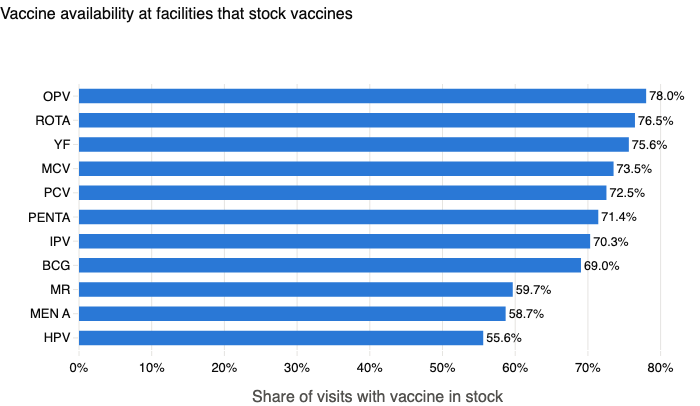

64.7% of facilities stock vaccines on site, 25.0% immunise without stocking and 10.3% offer no immunisation. Among stocking facilities, availability is lowest for HPV (55.6%) and MEN A (58.7%) - the newer antigens - and highest for OPV (78.0%).


In [47]:
r = q22(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q23. How much does cold chain status drive vaccine availability and immunisation delivery?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [48]:
def q23(con):
    sql = """
    SELECT CASE WHEN vaccine_fridge_functional_flag=1 THEN 'Working fridge' ELSE 'No working fridge' END AS fridge,
           CASE WHEN cold_chain_interruption_since_last_visit_flag=1 THEN 'Interruption' ELSE 'No interruption' END AS interruption,
           AVG(in_stock_flag) AS in_stock_rate, COUNT(*) AS n
    FROM v_vaccine GROUP BY 1,2"""
    df = q(con, sql)
    fig = px.bar(df, x="fridge", y="in_stock_rate", color="interruption", barmode="group", text="in_stock_rate",
                 title="Vaccine availability by cold chain status", color_discrete_sequence=T.SERIES)
    fig.update_traces(texttemplate="%{text:.1%}", textposition="outside", width=0.3)
    fig.update_layout(yaxis_tickformat=".0%", xaxis_title="", yaxis_title="Vaccine in stock", legend_title="", yaxis_range=[0, 1])
    imm = q(con, """SELECT vaccine_fridge_functional_flag f, AVG(immunization_sessions_all_conducted_flag) r FROM v_visits WHERE vaccine_stock_status='Yes' GROUP BY 1""").set_index("f").r
    best = df.loc[df.in_stock_rate.idxmax()]; worst = df.loc[df.in_stock_rate.idxmin()]
    ans = (f"Vaccine availability is {pct(best.in_stock_rate)} with a {best.fridge.lower()} and {best.interruption.lower()}, but {pct(worst.in_stock_rate)} with {worst.fridge.lower()} and {worst.interruption.lower()}. "
           f"Immunisation sessions were fully delivered in {pct(imm.get(1, np.nan))} of weeks where the fridge works versus {pct(imm.get(0, np.nan))} where it does not.")
    return Result("Q23", "Vaccines", "How much does cold chain status drive vaccine availability and immunisation delivery?", sql, df, ans, fig)

,fridge,interruption,in_stock_rate,n
0,No working fridge,Interruption,0.587,968
1,No working fridge,No interruption,0.699,1595
2,Working fridge,Interruption,0.582,660
3,Working fridge,No interruption,0.727,4631


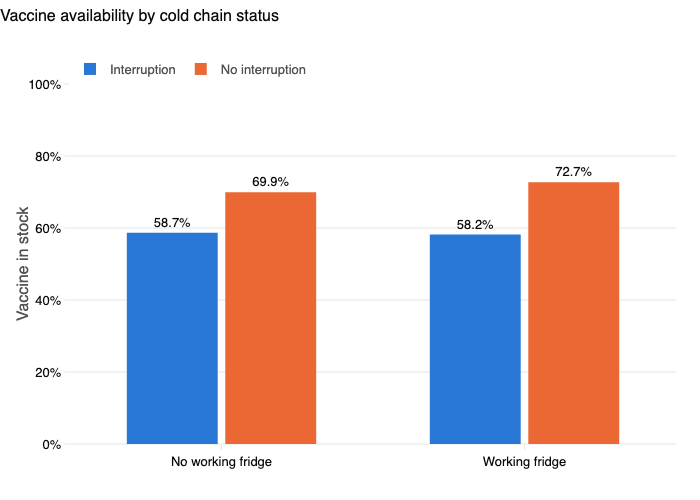

Vaccine availability is 72.7% with a working fridge and no interruption, but 58.2% with working fridge and interruption. Immunisation sessions were fully delivered in 81.5% of weeks where the fridge works versus 57.1% where it does not.


In [49]:
r = q23(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q24. Which vaccines are consumed most, and why?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [50]:
def q24(con):
    sql = """
    SELECT vaccine, SUM(most_dispensed_flag) AS weeks_most_dispensed, SUM(doses_used) AS doses_used FROM vaccine_stock GROUP BY 1 ORDER BY doses_used DESC"""
    df = q(con, sql)
    fig = hbar(df, "doses_used", "vaccine", "Doses used across all visits, by vaccine", xlabel="Doses", fmt=",.0f")
    reason = q(con, "SELECT reason_most_dispensed r, COUNT(*) n FROM vaccine_stock WHERE most_dispensed_flag=1 GROUP BY 1 ORDER BY n DESC")
    ans = (f"{df.iloc[0].vaccine}, {df.iloc[1].vaccine} and {df.iloc[2].vaccine} account for {pct(df.head(3).doses_used.sum()/df.doses_used.sum())} of doses used. "
           f"The most common driver of a high-dispensing week is '{reason.iloc[0].r}' ({pct(reason.iloc[0].n/reason.n.sum())}), and HPV demand is mostly school-based sessions.")
    return Result("Q24", "Vaccines", "Which vaccines are consumed most, and why?", sql, df, ans, fig)

,vaccine,weeks_most_dispensed,doses_used
0,OPV,511,27842
1,PCV,510,27587
2,PENTA,511,26815
3,ROTA,459,18656
4,IPV,470,13548
5,BCG,453,12143
6,MCV,437,9379
7,YF,416,9343
8,MR,431,7772
9,MEN A,436,6808


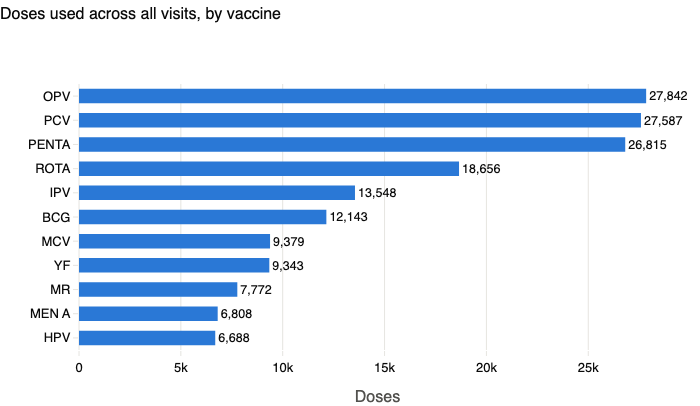

OPV, PCV and PENTA account for 49.4% of doses used. The most common driver of a high-dispensing week is 'Scheduled routine immunization session' (53.4%), and HPV demand is mostly school-based sessions.


In [51]:
r = q24(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

---
# Readiness

## Q25. Which LGAs are most and least ready to deliver services?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [52]:
def q25(con):
    sql = """
    SELECT lga, AVG(readiness_score) AS readiness, AVG(facility_open_on_arrival_flag) AS open_rate, AVG(attendance_rate) AS attendance,
           1-AVG(stockout_rate) AS stock_availability, AVG(vaccine_availability_rate) AS vaccine_availability, AVG(session_completion_rate) AS sessions
    FROM v_visits GROUP BY lga ORDER BY readiness DESC"""
    df = q(con, sql)
    fig = hbar(df, "readiness", "lga", "Composite facility readiness score by LGA (0-100)", xlabel="Readiness score", fmt=".1f")
    fig.update_xaxes(tickformat="")
    bands = q(con, "SELECT readiness_band b, COUNT(*) n FROM v_visits GROUP BY 1").set_index("b").n
    ans = (f"Average readiness is {df.readiness.mean():.1f}/100, from {df.iloc[-1].readiness:.1f} in {df.iloc[-1].lga} to {df.iloc[0].readiness:.1f} in {df.iloc[0].lga}. "
           f"{pct(bands.get('Critical',0)/bands.sum())} of visits score Critical (<50) and {pct(bands.get('Strong',0)/bands.sum())} Strong (>80).")
    return Result("Q25", "Readiness", "Which LGAs are most and least ready to deliver services?", sql, df, ans, fig, key_numbers={"mean_readiness": float(df.readiness.mean())})

,lga,readiness,open_rate,attendance,stock_availability,vaccine_availability,sessions
0,Sanga,84.929,0.938,0.778,0.817,0.809,0.862
1,Birnin Gwari,78.531,0.771,0.743,0.777,0.884,0.824
2,Ikara,77.146,0.854,0.696,0.811,0.758,0.805
3,Makarfi,74.106,0.833,0.694,0.742,0.689,0.795
4,Kaduna South,73.794,0.917,0.679,0.664,0.658,0.831
5,Kaura,73.673,0.854,0.719,0.713,0.684,0.810
6,Kagarko,73.119,0.812,0.731,0.663,0.738,0.798
7,Soba,72.013,0.771,0.704,0.719,0.664,0.788
8,Jema'a,71.277,0.729,0.718,0.636,0.674,0.804
9,Sabon Gari,70.856,0.750,0.790,0.745,0.705,0.791


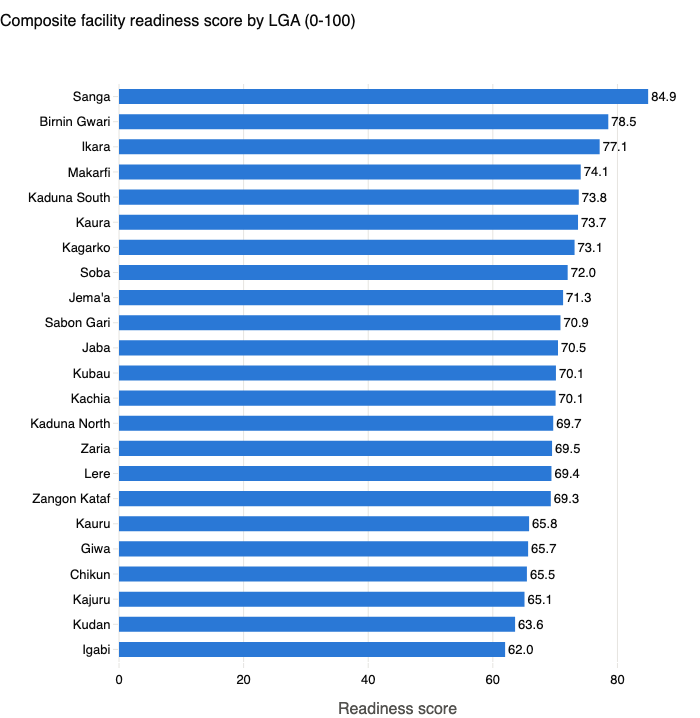

Average readiness is 70.7/100, from 62.0 in Igabi to 84.9 in Sanga. 7.5% of visits score Critical (<50) and 28.6% Strong (>80).


In [53]:
r = q25(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q26. How does readiness differ by level of care?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [54]:
def q26(con):
    sql = """
    SELECT facility_type, AVG(readiness_score) AS readiness, AVG(attendance_rate) AS attendance, 1-AVG(stockout_rate) AS stock_availability,
           AVG(session_completion_rate) AS sessions, AVG(cce_functionality_rate) AS cold_chain, AVG(facility_open_on_arrival_flag) AS open_rate
    FROM v_visits GROUP BY 1"""
    df = q(con, sql)
    long = df.melt(id_vars=["facility_type", "readiness"], var_name="pillar", value_name="rate")
    fig = px.bar(long, x="pillar", y="rate", color="facility_type", barmode="group", text="rate", title="Readiness pillars by facility type",
                 category_orders={"facility_type": C.FACILITY_TYPES}, color_discrete_sequence=T.SERIES)
    fig.update_traces(texttemplate="%{text:.0%}", textposition="outside", width=0.18)
    fig.update_layout(yaxis_tickformat=".0%", xaxis_title="", yaxis_title="", legend_title="", yaxis_range=[0, 1.05])
    d = df.set_index("facility_type")
    ans = (f"General Hospitals score {d.loc['General Hospital','readiness']:.1f} and Health Posts {d.loc['Health Post','readiness']:.1f}. "
           f"Health Posts lag most on cold chain ({pct(d.loc['Health Post','cold_chain'])}) and being open on arrival ({pct(d.loc['Health Post','open_rate'])}), which argues for a differentiated support package by level of care.")
    return Result("Q26", "Readiness", "How does readiness differ by level of care?", sql, df, ans, fig)

,facility_type,readiness,attendance,stock_availability,sessions,cold_chain,open_rate
0,Basic Health Centre,68.322,0.667,0.670,0.764,0.763,0.785
1,General Hospital,75.932,0.737,0.709,0.810,0.861,0.778
2,Health Post,63.170,0.639,0.661,0.748,0.758,0.770
3,Primary Health Centre,73.939,0.710,0.701,0.794,0.800,0.827


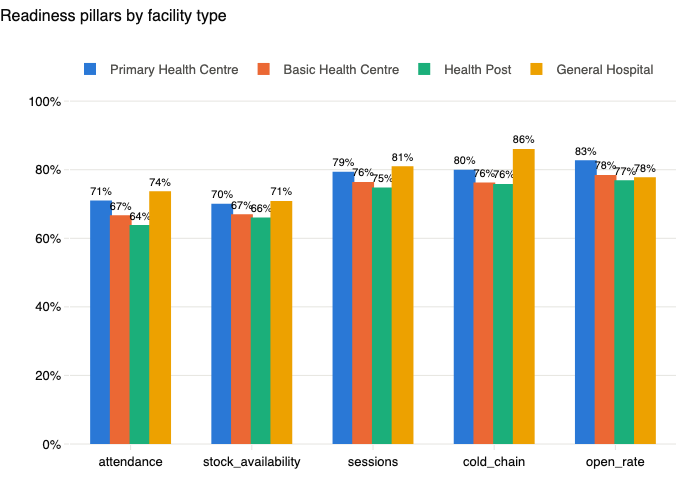

General Hospitals score 75.9 and Health Posts 63.2. Health Posts lag most on cold chain (75.8%) and being open on arrival (77.0%), which argues for a differentiated support package by level of care.


In [55]:
r = q26(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q27. Which individual facilities need urgent support?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [56]:
def q27(con):
    sql = """
    SELECT f.facility_id, f.facility_name, f.lga, f.facility_type, AVG(v.readiness_score) AS readiness, AVG(v.stockout_rate) AS stockout_rate,
           AVG(v.attendance_rate) AS attendance, AVG(v.facility_open_on_arrival_flag) AS open_rate, COUNT(*) AS visits
    FROM facility_visits v JOIN facilities f USING(facility_id) GROUP BY 1,2,3,4 ORDER BY readiness"""
    df = q(con, sql)
    bottom = df.head(15)
    fig = hbar(bottom, "readiness", "facility_name", "15 lowest-readiness facilities (mean across rounds)", color="lga", xlabel="Readiness score", fmt=".1f")
    fig.update_xaxes(tickformat=""); fig.update_layout(legend_title="")
    ans = (f"The 15 lowest-scoring facilities average {bottom.readiness.mean():.1f}/100, with attendance of {pct(bottom.attendance.mean())} and a {pct(bottom.stockout_rate.mean())} stock-out rate. "
           f"{bottom.lga.value_counts().index[0]} contributes the most facilities to this list. These are the candidates for an intensive support visit this quarter.")
    return Result("Q27", "Readiness", "Which individual facilities need urgent support?", sql, df, ans, fig)

,facility_id,facility_name,lga,facility_type,readiness,stockout_rate,attendance,open_rate,visits
0,KD-024,Tudun Madaki PHC,Giwa,Primary Health Centre,48.383,0.457,0.601,0.500,6
1,KD-164,Rafin Dan Gama HP,Soba,Health Post,48.383,0.574,0.500,0.500,6
2,KD-125,Kofar Gari HP,Kudan,Health Post,49.950,0.492,0.500,0.667,6
3,KD-109,Gidan Wada PHC,Kauru,Primary Health Centre,50.700,0.572,0.541,0.667,6
4,KD-027,Rafin Kaji HP,Igabi,Health Post,52.267,0.250,0.500,0.500,6
5,KD-128,Tudun Sarki HP,Kudan,Health Post,52.267,0.583,0.583,0.667,6
6,KD-172,Rigasa Fada HP,Zangon Kataf,Health Post,53.567,0.442,0.583,0.667,6
7,KD-032,Rigasa Sarki HP,Igabi,Health Post,53.633,0.426,0.553,0.833,6
8,KD-096,Sabon Dan Gama HP,Kajuru,Health Post,53.867,0.537,0.333,0.667,6
9,KD-053,Badarawa Kaji BHC,Jema'a,Basic Health Centre,53.967,0.594,0.604,0.167,6


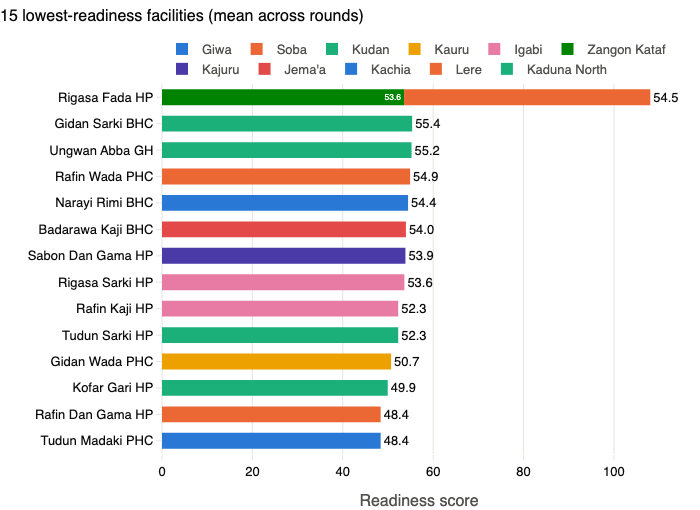

The 15 lowest-scoring facilities average 52.8/100, with attendance of 54.0% and a 50.6% stock-out rate. Kudan contributes the most facilities to this list. These are the candidates for an intensive support visit this quarter.


In [57]:
r = q27(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q28. How are indicators trending across the bi-weekly rounds?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [58]:
def q28(con):
    sql = """
    SELECT round_name, round_number, AVG(readiness_score) AS readiness, AVG(stockout_rate) AS stockout_rate, AVG(vaccine_availability_rate) AS vaccine_availability,
           AVG(facility_open_on_arrival_flag) AS open_rate, AVG(cold_chain_interruption_since_last_visit_flag) AS cold_chain_interruption
    FROM v_visits GROUP BY 1,2 ORDER BY 2"""
    df = q(con, sql)
    fig = go.Figure()
    for col, name in [("stockout_rate", "Commodity stock-out rate"), ("vaccine_availability", "Vaccine availability"), ("open_rate", "Open on arrival"), ("cold_chain_interruption", "Cold chain interruption")]:
        fig.add_trace(go.Scatter(x=df.round_name, y=df[col], mode="lines+markers", name=name, line=dict(width=2), marker=dict(size=9)))
    fig.update_layout(title="Key indicators across visit rounds", yaxis_tickformat=".0%", xaxis_title="", yaxis_title="", hovermode="x unified")
    ans = (f"Commodity stock-outs rose from {pct(df.iloc[0].stockout_rate)} at baseline to {pct(df.iloc[-1].stockout_rate)} by {df.iloc[-1].round_name} as opening balances were drawn down faster than deliveries replaced them, "
           f"while vaccine availability held around {pct(df.vaccine_availability.mean())}. The trend, not the level, is the alarm: resupply cadence is not keeping pace with consumption.")
    return Result("Q28", "Readiness", "How are indicators trending across the bi-weekly rounds?", sql, df, ans, fig)

,round_name,round_number,readiness,stockout_rate,vaccine_availability,open_rate,cold_chain_interruption
0,Baseline,1,74.333,0.175,0.827,0.772,0.188
1,Bi-weekly 1,2,72.548,0.261,0.742,0.766,0.203
2,Bi-weekly 2,3,70.899,0.337,0.680,0.832,0.239
3,Bi-weekly 3,4,65.310,0.352,0.645,0.701,0.203
4,Bi-weekly 4,5,70.804,0.372,0.626,0.875,0.210
5,Bi-weekly 5,6,70.177,0.387,0.631,0.859,0.196


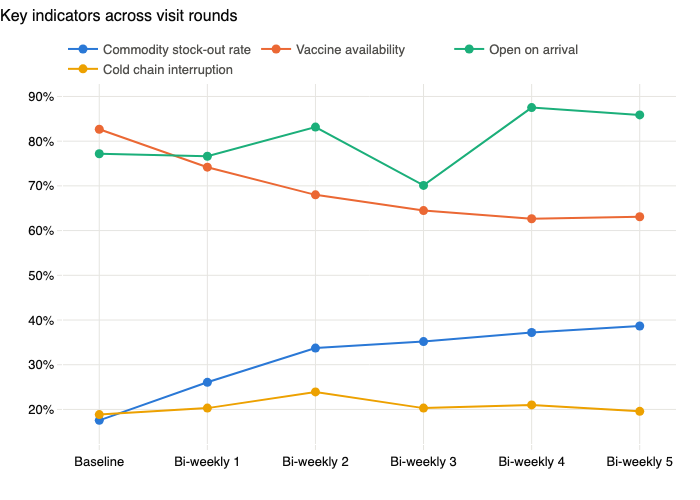

Commodity stock-outs rose from 17.5% at baseline to 38.7% by Bi-weekly 5 as opening balances were drawn down faster than deliveries replaced them, while vaccine availability held around 69.2%. The trend, not the level, is the alarm: resupply cadence is not keeping pace with consumption.


In [59]:
r = q28(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q29. Which factors move together, and what are the strongest levers on readiness?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [60]:
def q29(con):
    sql = """
    SELECT readiness_score, attendance_rate, stockout_rate, vaccine_availability_rate, session_completion_rate, cce_functionality_rate,
           salary_paid_on_time_last_3_months_flag, requisition_submitted_last_cycle_flag, roster_updated_this_week_flag,
           distance_to_lga_hq_km, total_health_workers, security_incident_reported_flag, facility_open_on_arrival_flag
    FROM v_visits"""
    df = q(con, sql)
    corr = df.corr(numeric_only=True)
    labels = {"readiness_score": "Readiness", "attendance_rate": "Attendance", "stockout_rate": "Stock-out rate", "vaccine_availability_rate": "Vaccine availability",
              "session_completion_rate": "Session completion", "cce_functionality_rate": "Cold chain functional", "salary_paid_on_time_last_3_months_flag": "Salary on time",
              "requisition_submitted_last_cycle_flag": "Requisition submitted", "roster_updated_this_week_flag": "Roster updated", "distance_to_lga_hq_km": "Distance to LGA HQ",
              "total_health_workers": "Health workers", "security_incident_reported_flag": "Security incident", "facility_open_on_arrival_flag": "Open on arrival"}
    corr = corr.rename(index=labels, columns=labels)
    fig = go.Figure(go.Heatmap(z=corr.values, x=corr.columns, y=corr.index, zmin=-1, zmax=1, colorscale=[[0, T.DIVERGING[0]], [0.5, T.DIVERGING[2]], [1, T.DIVERGING[4]]],
                               text=np.round(corr.values, 2), texttemplate="%{text}", hovertemplate="%{y} vs %{x}: %{z:.2f}<extra></extra>", xgap=2, ygap=2))
    fig.update_layout(title="Correlation between readiness drivers", height=560, xaxis=dict(tickangle=-40), yaxis=dict(autorange="reversed"))
    s = corr["Readiness"].drop("Readiness").sort_values()
    ans = (f"Readiness correlates most positively with {s.index[-1]} (r={s.iloc[-1]:.2f}) and {s.index[-2]} (r={s.iloc[-2]:.2f}), and most negatively with {s.index[0]} (r={s.iloc[0]:.2f}). "
           f"Salary timeliness (r={corr.loc['Readiness','Salary on time']:.2f}) and requisition submission (r={corr.loc['Readiness','Requisition submitted']:.2f}) are the strongest management levers.")
    return Result("Q29", "Readiness", "Which factors move together, and what are the strongest levers on readiness?", sql, corr.reset_index(), ans, fig)

,index,Readiness,Attendance,Stock-out rate,Vaccine availability,Session completion,Cold chain functional,Salary on time,Requisition submitted,Roster updated,Distance to LGA HQ,Health workers,Security incident,Open on arrival
0,Readiness,1.000,0.539,-0.418,0.542,0.494,0.414,0.235,0.184,0.173,-0.005,0.295,-0.299,0.572
1,Attendance,0.539,1.000,-0.140,0.213,0.353,0.147,0.335,0.053,0.270,-0.127,0.159,-0.296,0.129
2,Stock-out rate,-0.418,-0.140,1.000,-0.282,-0.110,-0.073,-0.052,-0.452,-0.129,-0.066,-0.121,0.020,-0.006
3,Vaccine availability,0.542,0.213,-0.282,1.000,0.201,0.195,0.142,0.060,0.131,0.114,0.362,-0.057,0.070
4,Session completion,0.494,0.353,-0.110,0.201,1.000,0.131,0.310,0.030,0.064,-0.023,0.127,-0.429,0.126
5,Cold chain functional,0.414,0.147,-0.073,0.195,0.131,1.000,0.049,0.055,0.091,0.048,0.194,-0.003,0.005
6,Salary on time,0.235,0.335,-0.052,0.142,0.310,0.049,1.000,-0.031,0.027,0.011,0.034,-0.029,0.063
7,Requisition submitted,0.184,0.053,-0.452,0.060,0.030,0.055,-0.031,1.000,0.114,0.119,0.095,0.028,0.041
8,Roster updated,0.173,0.270,-0.129,0.131,0.064,0.091,0.027,0.114,1.000,0.027,0.151,-0.019,-0.024
9,Distance to LGA HQ,-0.005,-0.127,-0.066,0.114,-0.023,0.048,0.011,0.119,0.027,1.000,0.004,0.024,0.008


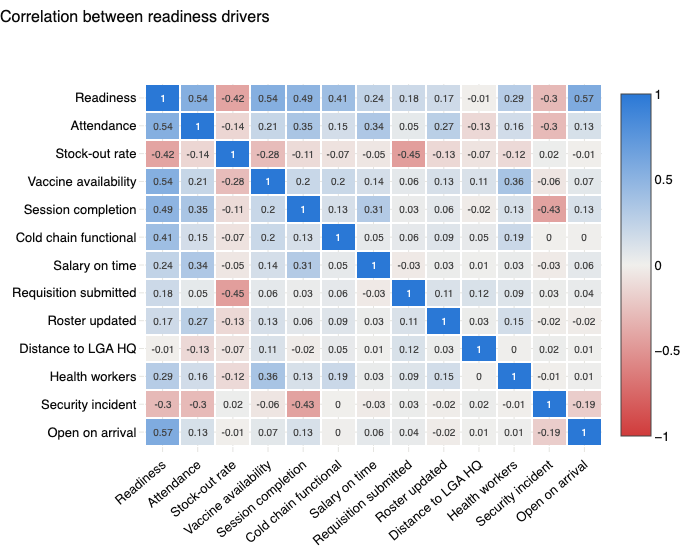

Readiness correlates most positively with Open on arrival (r=0.57) and Vaccine availability (r=0.54), and most negatively with Stock-out rate (r=-0.42). Salary timeliness (r=0.24) and requisition submission (r=0.18) are the strongest management levers.


In [61]:
r = q29(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Q30. Where are the weakest facilities located?

The cell below defines the analysis for this question (SQL + figure), then runs it.

In [62]:
def q30(con):
    sql = """
    SELECT f.facility_name, f.lga, f.facility_type, f.latitude, f.longitude, AVG(v.readiness_score) AS readiness, AVG(v.stockout_rate) AS stockout_rate, AVG(v.attendance_rate) AS attendance
    FROM facility_visits v JOIN facilities f USING(facility_id) GROUP BY 1,2,3,4,5"""
    df = q(con, sql)
    fig = px.scatter_map(df, lat="latitude", lon="longitude", color="readiness", size="stockout_rate", size_max=16, hover_name="facility_name",
                         hover_data={"lga": True, "facility_type": True, "readiness": ":.1f", "stockout_rate": ":.1%", "attendance": ":.1%", "latitude": False, "longitude": False},
                         color_continuous_scale=T.SEQUENTIAL, zoom=6.6, center=dict(lat=10.35, lon=7.7), title="Facility readiness map (colour = readiness, size = stock-out rate)")
    fig.update_layout(map_style="carto-positron", height=620, margin=dict(l=0, r=0, t=56, b=0), coloraxis_colorbar=dict(title="Readiness"))
    lga = df.groupby("lga").readiness.mean().sort_values()
    sec = q(con, "SELECT security_risk_lga s, AVG(readiness_score) r FROM v_visits GROUP BY 1").set_index("s").r
    ans = (f"The lowest-readiness clusters are {', '.join(lga.index[:3])} (mean {lga.iloc[:3].mean():.1f}) while {', '.join(lga.index[-3:])} perform best (mean {lga.iloc[-3:].mean():.1f}). "
           f"Facilities in security-risk LGAs average {sec.get(1, np.nan):.1f} versus {sec.get(0, np.nan):.1f} elsewhere - geography and security explain a large share of the variation.")
    return Result("Q30", "Readiness", "Where are the weakest facilities located?", sql, df, ans, fig)

,facility_name,lga,facility_type,latitude,longitude,readiness,stockout_rate,attendance
0,Badarawa Dan Gama PHC,Kauru,Primary Health Centre,10.107,8.228,73.217,0.343,0.696
1,Badarawa Dan Gama PHC,Sanga,Primary Health Centre,9.431,8.472,88.117,0.174,0.852
2,Badarawa Fada BHC,Igabi,Basic Health Centre,10.751,7.660,64.367,0.471,0.563
3,Badarawa Fada PHC,Birnin Gwari,Primary Health Centre,10.665,6.582,85.783,0.181,0.883
4,Badarawa Kaji BHC,Jema'a,Basic Health Centre,9.354,8.436,53.967,0.594,0.604
5,Badarawa Kaji BHC,Kagarko,Basic Health Centre,9.502,7.798,80.100,0.457,0.853
6,Badarawa Kaji BHC,Zangon Kataf,Basic Health Centre,9.707,8.224,61.783,0.198,0.547
7,Badarawa Kaji PHC,Chikun,Primary Health Centre,10.253,7.306,56.300,0.519,0.728
8,Badarawa Kaji PHC,Jaba,Primary Health Centre,9.575,8.016,88.733,0.087,0.813
9,Badarawa Rimi HP,Kudan,Health Post,11.151,7.847,59.783,0.333,0.590


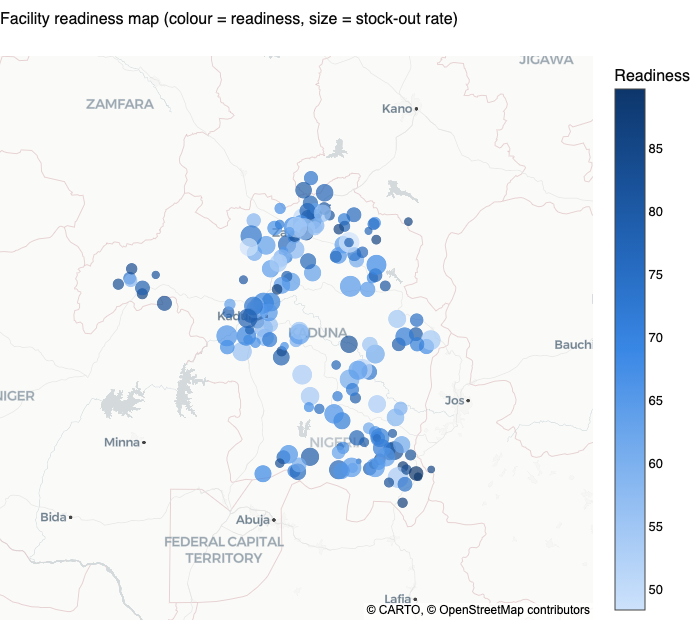

The lowest-readiness clusters are Igabi, Kudan, Kajuru (mean 63.5) while Ikara, Birnin Gwari, Sanga perform best (mean 80.2). Facilities in security-risk LGAs average 67.8 versus 71.7 elsewhere - geography and security explain a large share of the variation.


In [63]:
r = q30(con)
display(r.data.head(15))
r.figure.show()
print(r.answer)
results.append(r)

## Summary of answers

Every answer above, collected in one table (also written to `outputs/analysis_results.json` by the pipeline).


In [64]:
summary = pd.DataFrame([{"id": r.id, "section": r.section, "question": r.question, "answer": r.answer} for r in results])
pd.set_option("display.max_colwidth", None)
summary.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}).hide(axis="index")


id,section,question,answer
Q01,Facility access,"How often are facilities actually open when a data champion arrives, and where is access weakest?","Facilities were open on arrival in 80.1% of 1104 visits. Where closed, data champions waited 46 minutes on average. Kauru is the weakest LGA (68.8%) and Sanga the strongest (93.8%)."
Q02,Facility access,What are the main reasons facilities are closed when visited?,"The leading cause of a closed facility is 'Staff not yet arrived' (30.0% of 220 cases). Insecurity accounts for 17.7%, concentrated in security-risk LGAs."
Q03,Facility access,"What are facility operating hours, and can facilities refer emergencies with transport?","41.8% of facilities report 24-hour operation, driven by PHCs and General Hospitals; most Health Posts run 6-8 hour days. 78.2% of visits confirmed the facility can refer obstetric emergencies, but transport was available when needed in only 59.1% of those."
Q04,Cold chain,"How functional is the cold chain, and how often is it interrupted?","Where equipment exists, functionality ranges from 74.5% (Rush (3L)) to 82.2% (Refrigerators). Only 66.4% of facilities with cold chain equipment have at least one working vaccine refrigerator, and 20.7% of visits recorded a cold chain interruption since the previous visit, most often 'Power failure / no electricity'."
Q05,Service delivery,"Which services do facilities offer, and how reliably are planned sessions delivered?","Malaria and ANC are near-universal, while Nutrition (69.6%) and Labour & Delivery are the least available. Planned sessions were fully delivered in 78.0% of service-weeks; Immunization has the lowest completion (75.4%)."
Q06,Service delivery,What stops planned sessions from happening?,"'Staff unavailable (leave, redeployment, strike)' explains 32.6% of missed sessions - a human-resource problem before a supply problem. Security concerns account for 10.2% and vaccine or cold-chain issues for 4.6%."
Q07,Service delivery,What is training coverage across the network?,77.2% of facilities had any staff trained in the past two years. Coverage is highest for Life Saving Skills (28.3%) and lowest for Nutrition / IYCF (18.5%); no single training reaches half of facilities.
Q08,Human resources,What does the workforce look like by cadre and employment type?,"The network has 4,652 health workers: 65.4% permanent, 20.7% ad hoc/seconded and 13.8% volunteers. CHEWs and JCHEWs form the backbone; 38.1% of PHCs have no permanent doctor and 9.1% of PHCs/BHCs have no permanent nurse or midwife. Women make up 55.1% of the workforce."
Q09,Human resources,"How high is absenteeism, and which cadres are most affected?","Across all visits, 72.0% of permanent staff scheduled for duty were actually present - an absenteeism rate of 28.0%. JCHEWs are least reliably present (68.6%); Pharmacy Technicians most (75.8%)."
Q10,Human resources,Where is absenteeism geographically concentrated?,Attendance ranges from 57.6% in Igabi to 79.7% in Sanga - a 22-point spread that points to LGA-level management and security effects rather than individual behaviour.


In [65]:
con.close()